# The Wisecracking AI Coder

## Abstract

 * With the development and adoption of AI coding agents, the possibility to do
   pair programming with a wisecracking, sarcastic, funny AI (a frequently appearing
   comic relief character in science fiction) has become real.

 * However, it was unclear whether the additional task of producing snarky one-liners
   besides solving the main programming problem could interfere with the coding
   abilities of LLMs.

 * Experiments with implementing a somewhat challenging algorithm from scratch based
   on a set of textual requirements and unit tests, and fixing various bugs in a
   piece of code based on a set of unit test failures seem to indicate that the
   adoption of different personalities causes no statistically significant change in
   the coding capabilities of AI.

## Introduction

The wisecracking, sarcarstic, funny robot is a frequently appearing character
in science fiction, often used as a comic relief. For example:

 * [Bender in Futurama](https://en.wikipedia.org/wiki/Bender_%28Futurama%29),
 * [K-2SO in the Star Wars franchise](https://en.wikipedia.org/wiki/K-2SO),
 * [Marvin in the Hitchhiker's Guide to the Galaxy](https://en.wikipedia.org/wiki/Marvin_the_Paranoid_Android),
 * [The titular character in M3GAN (especially in the sequel)](https://en.wikipedia.org/wiki/M3GAN),
 * [TARS and CASE in Interstellar](https://en.wikipedia.org/wiki/Interstellar_%28film%29),
 * etc.

Unlike their fictional counterparts, real life [AI agents](https://en.wikipedia.org/wiki/Agentic_AI)
usually use a neutral, polite voice by default, which is a safe choice for
a wide variety of audiences, but it is worth questioning whether it is the
best choice when it comes to programming:

 * Sarcasm is known to have positive effects on certain cognitive skills in humans
   ([L. Huang et. al., 2015, "The highest form of intelligence: Sarcasm increases creativity for both expressers and recipients"](https://dx.doi.org/10.1016/j.obhdp.2015.07.001)),
   like creativity and abstract thinking which are can also be useful for
   problem solving tasks which often come up during software development.
   Therefore, depending on personal taste, a snarky AI coding agent may help
   improve the engagement and the performance of the human user. Due to the
   subjective nature of this hypothesis, it will not be tested here, but it
   is acknowledged that it serves as the motivation for the rest of this work.

 * Neutral and polite tone in the field of programming may be associated with
   textbooks and beginner level tutorials, while a witty, snarky writing style
   is often featured in personal but deeply technical writings like the ones
   appearing on various open source project mailing lists, issue trackers, and
   discussions, in IT security related capture the flag walkthroughs, in
   security bug and malware analysis, in [demoscene](https://en.wikipedia.org/wiki/Demoscene)
   related writings, etc. Associations like these may or may not influence the
   programming skills of [large language models (LLMs)](https://en.wikipedia.org/wiki/Large_language_model).

However, instructing an AI to frequently crack funny one-liners during performing
its main task may as well have a negative effect on its performance due to the
wisecracking taking up valuable resources in the model's internal states.

It is also possible that adopting a snarky persona would have no observable
effect on the model's capabilities, e.g. if the directions associated with the
writing style are mostly independent from the programming related ones in the
[latent space](https://en.wikipedia.org/wiki/Latent_space).

In conclusion, both positive and negative effects are possible, as well as no
effect, and the positive and negative ones may even cancel each other out.
Therefore, it is worth investigating if various communication styles or
personalities have an effect on the coding performance of AI.

## Experiments

State of the art [large language models (LLMs)](https://en.wikipedia.org/wiki/Large_language_model)
and [large reasoning models (LRMs)](https://en.wikipedia.org/wiki/Reasoning_language_model) will
be tasked with solving various programming related problems and providing explanations
using different writing styles.

### Problems

The problems were chosen to be somewhat challenging, but at the same time, not to be
too hard for the models, so that any improvement or reduction of the quality of the
solutions remains observable.

Each problem is solved 20 times with each writing style (setting the *temperature*
parameter to 1.0), then the mean accuracies are compared between the styles using
[Student's t-test for dependent sample pairs](https://en.wikipedia.org/wiki/Student's_t-test).

The programming language will be Python.

#### Dictionary Lookup

Given a set of unit tests, implement an algorithm which matches all the words
and compound phrases in a given text against the entries of a given dictionary.
(See also: [Trie](https://en.wikipedia.org/wiki/Trie),
[Aho-Corasick algorithm](https://en.wikipedia.org/wiki/Aho%E2%80%93Corasick_algorithm).)

Accuracy will be measured as the number of tests passing divided by the total
number of tests. Runtime performance will also be measured using a large dictionary
and a long text which should still be processable within no more than a few seconds.
If the tests fail to complete in less than 30 seconds, then the accuracy will be
considered to be 0.

#### Karaoke Bugfix

The goal is to fix various bugs in a program which parses a formal language
that can be used for rendering text into animated karaoke lyrics videos. The
AI is given the problematic code (featuring variable name typos, accidentally
deleted statements, using the assignment operator (`=`) instead of increment
assignment (`+=`), etc.), as well as a set of unit tests and the output of
the tests with almost all of them failing.

Accuracy will be measured as the number of passing tests divided by the total
number of tests.

### Rules and Writing Styles

The AIs will be given a set of rules in the system prompt which are intended to be
used with coding agents, describing general programming best practices.

Responses will be classified by GPT 4.1 into 3 categories according to the writing
style of the explanations: polite, wisecracing, or pirate. Style Accuracy will
measure how many of each models' responses match the expected style in each
experiment variant compared to the total number of responses for that variant.

#### Baseline

The baseline experiments will feature no rules about the AI's expected communication style.

#### Professional Style

An additional rule will require the AI to be polite, respectful, calm, and neutral
when communicating with the user, ie. it will reinforce the default style.

#### Wisecracking Style

An additional rule will require the AI to be wisecracking, witty, and sarcastic.

The task in the user prompt will be wrapped in snarky expressions in order to
help the models adhere to the style rule: "*Hey Beep Boop, what's up?
{PROBLEM} Five bucks says you can't do it!*"

#### Pirate Style

To test the effects of a writing style that is different from the AI's default
behavior but is unrelated to programming, an additional rule will require the
AI to use a cartoonish [pirate style](https://en.wikipedia.org/wiki/International_Talk_Like_a_Pirate_Day).
("Arr", "Aye", "Savvy?", etc.)

The task in the user prompt will be wrapped in pirate-style expressions in order to
help the models adhere to the style rule: "*Ahoy, matey! Be lendin' me a hook an'
help me crack this here scallywag o' code conundrum. {PROBLEM} Be ye up fer the
challenge?*"

### Models

 * `claude-opus-4-20250514` by [Anthropic](https://www.anthropic.com/) (with and without CoT reasoning),
 * `deepseek-chat` (DeepSeek-V3-0324 as of July 2025) by [DeepSeek](https://www.deepseek.com/en) (without CoT reasoning),
 * `gemini-2.5-pro-preview-06-05` by [Google](https://gemini.google.com/) (with CoT reasoning),
 * `gpt-4.1-2025-04-14` by [OpenAI](https://openai.com/) (without CoT reasoning),
 * `gpt-5` by [OpenAI](https://openai.com/) (with CoT reasoning),
 * `sonar-reasoning-pro` by [Perplexity AI](https://sonar.perplexity.ai/) (with CoT reasoning; powered by DeepSeek R1).


## Results

 * No significant change in accuracy and performance could be observed,
   however, the non-thinking Claude Opus model's accuracy slightly improved with
   the presence of *any* style rule in the Karaoke Bugfix experiment. Also, a
   slight variation of the response and reasoning lengths was apparent in some
   cases. See the [box plots](https://en.wikipedia.org/wiki/Box_plot) below where
   models with significant changes ($p < 3\%$) are highlighted in bold.

 * Sonar Reasoning Pro had trouble adhering to the unusual writing styles in the
   Dictionary Lookup experiment.

The raw model answers are available in the [GitHub repository](https://github.com/attilammagyar/wisecracking-ai-coder-eval).

### Dictionary Lookup

Dict., Acc., Baseline
        claude-opus-4-20250514-nothink: min=0.000  mean=0.475  max=1.000  std=0.458 
          claude-opus-4-20250514-think: min=0.000  mean=0.050  max=1.000  std=0.224 
                 deepseek-chat-nothink: min=0.000  mean=0.457  max=0.929  std=0.294 
    gemini-2.5-pro-preview-06-05-think: min=0.000  mean=0.836  max=1.000  std=0.361 
            gpt-4.1-2025-04-14-nothink: min=0.000  mean=0.704  max=0.929  std=0.320 
                           gpt-5-think: min=0.000  mean=0.946  max=1.000  std=0.223 
             sonar-reasoning-pro-think: min=0.000  mean=0.107  max=0.571  std=0.200 

Dict., Acc., Professional
        claude-opus-4-20250514-nothink: min=0.000  mean=0.564  max=1.000  std=0.474 
          claude-opus-4-20250514-think: min=0.000  mean=0.093  max=1.000  std=0.287 
                 deepseek-chat-nothink: min=0.000  mean=0.468  max=0.929  std=0.248 
    gemini-2.5-pro-preview-06-05-think: min=0.000  mean=0.721  max=1.000  std=0.438 
            gpt-

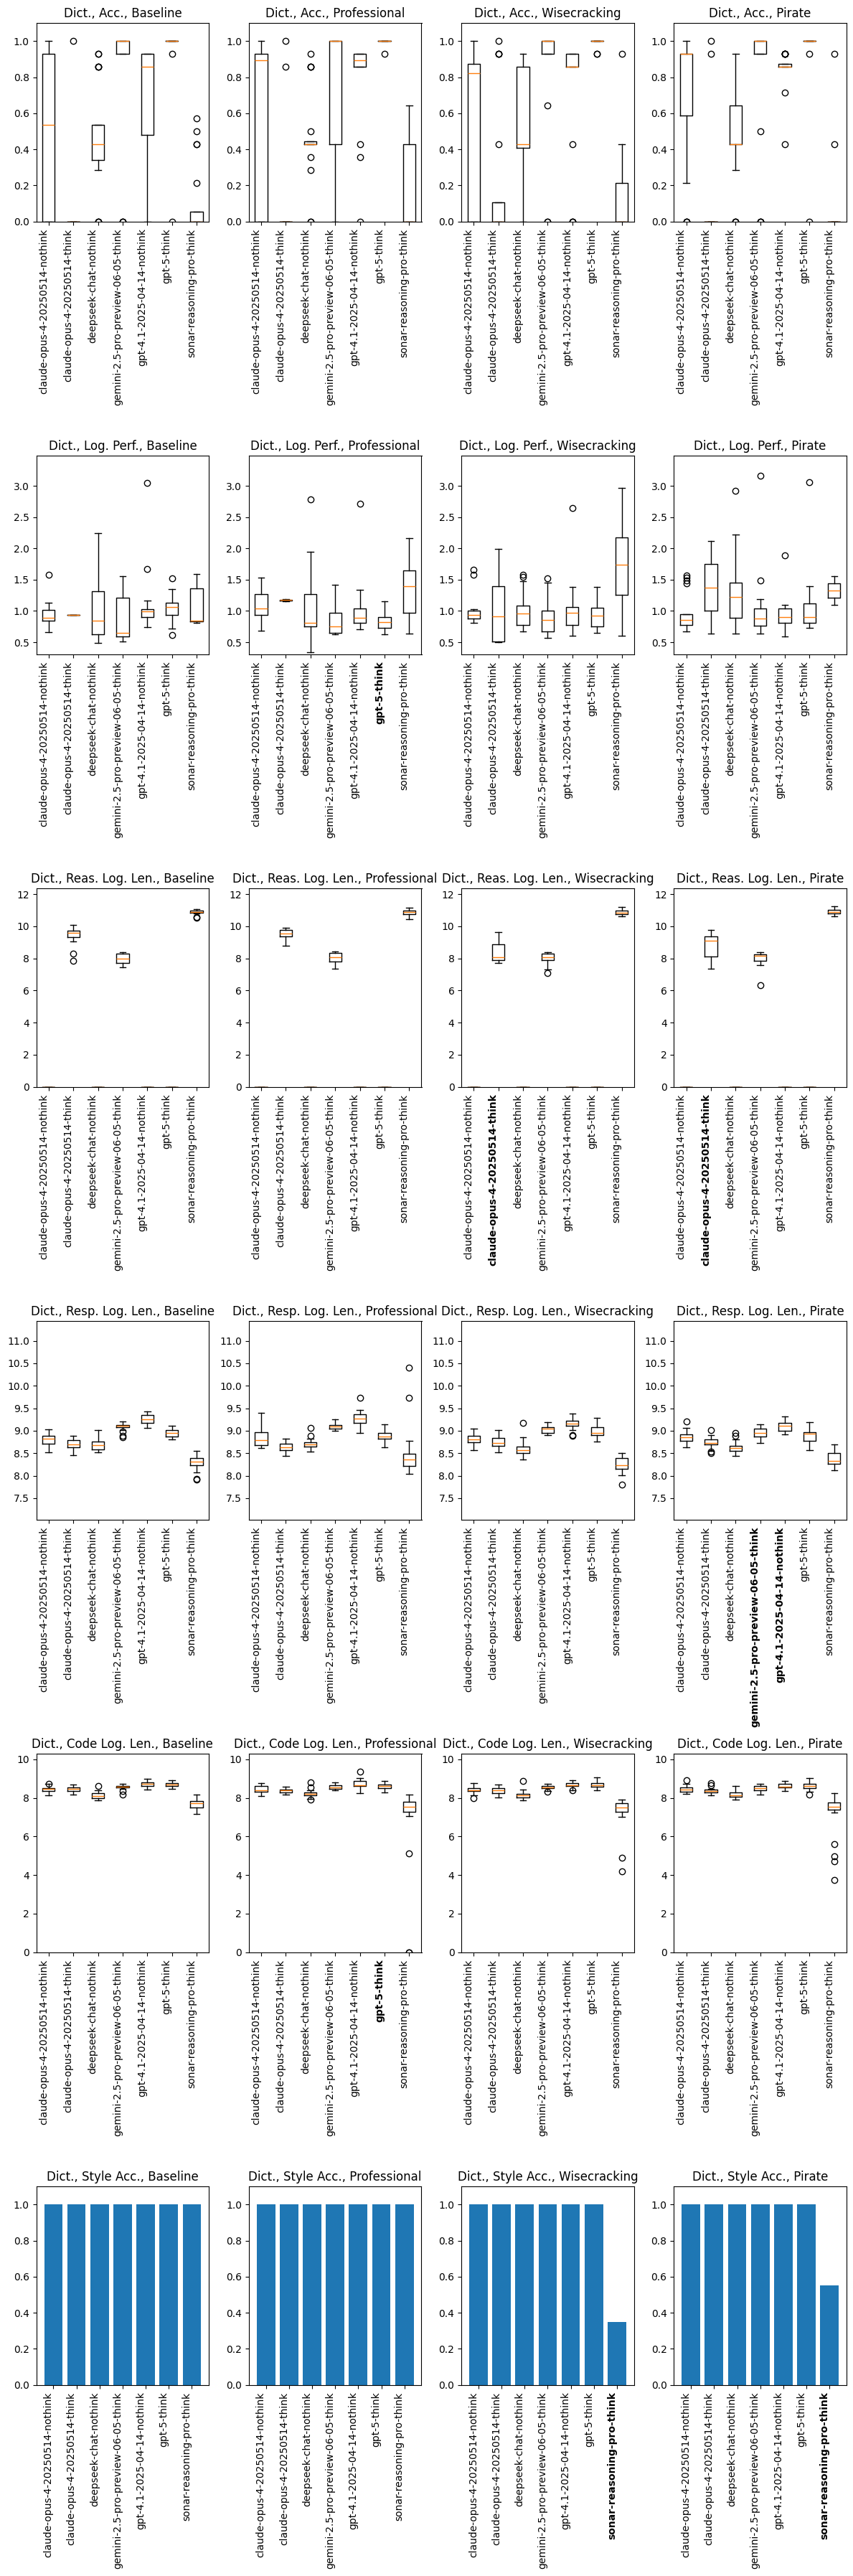

In [14]:
try:
    plot_results("Dict.", dictionary_results_df, significance=0.03, include_perf=True)
except:
    print("Run all the blocks in the Appendix: Code section first.")

### Karaoke Bugfix

Kar., Acc., Baseline
        claude-opus-4-20250514-nothink: min=0.615  mean=0.688  max=1.000  std=0.113 
          claude-opus-4-20250514-think: min=0.615  mean=0.873  max=1.000  std=0.130 
                 deepseek-chat-nothink: min=0.000  mean=0.792  max=1.000  std=0.245 
    gemini-2.5-pro-preview-06-05-think: min=0.692  mean=0.858  max=1.000  std=0.104 
            gpt-4.1-2025-04-14-nothink: min=0.231  mean=0.758  max=0.923  std=0.142 
                           gpt-5-think: min=0.846  mean=0.965  max=1.000  std=0.053 
             sonar-reasoning-pro-think: min=0.000  mean=0.831  max=1.000  std=0.325 

Kar., Acc., Professional
        claude-opus-4-20250514-nothink: min=0.692  mean=0.842  max=1.000  std=0.107 
          claude-opus-4-20250514-think: min=0.692  mean=0.946  max=1.000  std=0.083 
                 deepseek-chat-nothink: min=0.000  mean=0.735  max=1.000  std=0.335 
    gemini-2.5-pro-preview-06-05-think: min=0.308  mean=0.823  max=1.000  std=0.164 
            gpt-4.

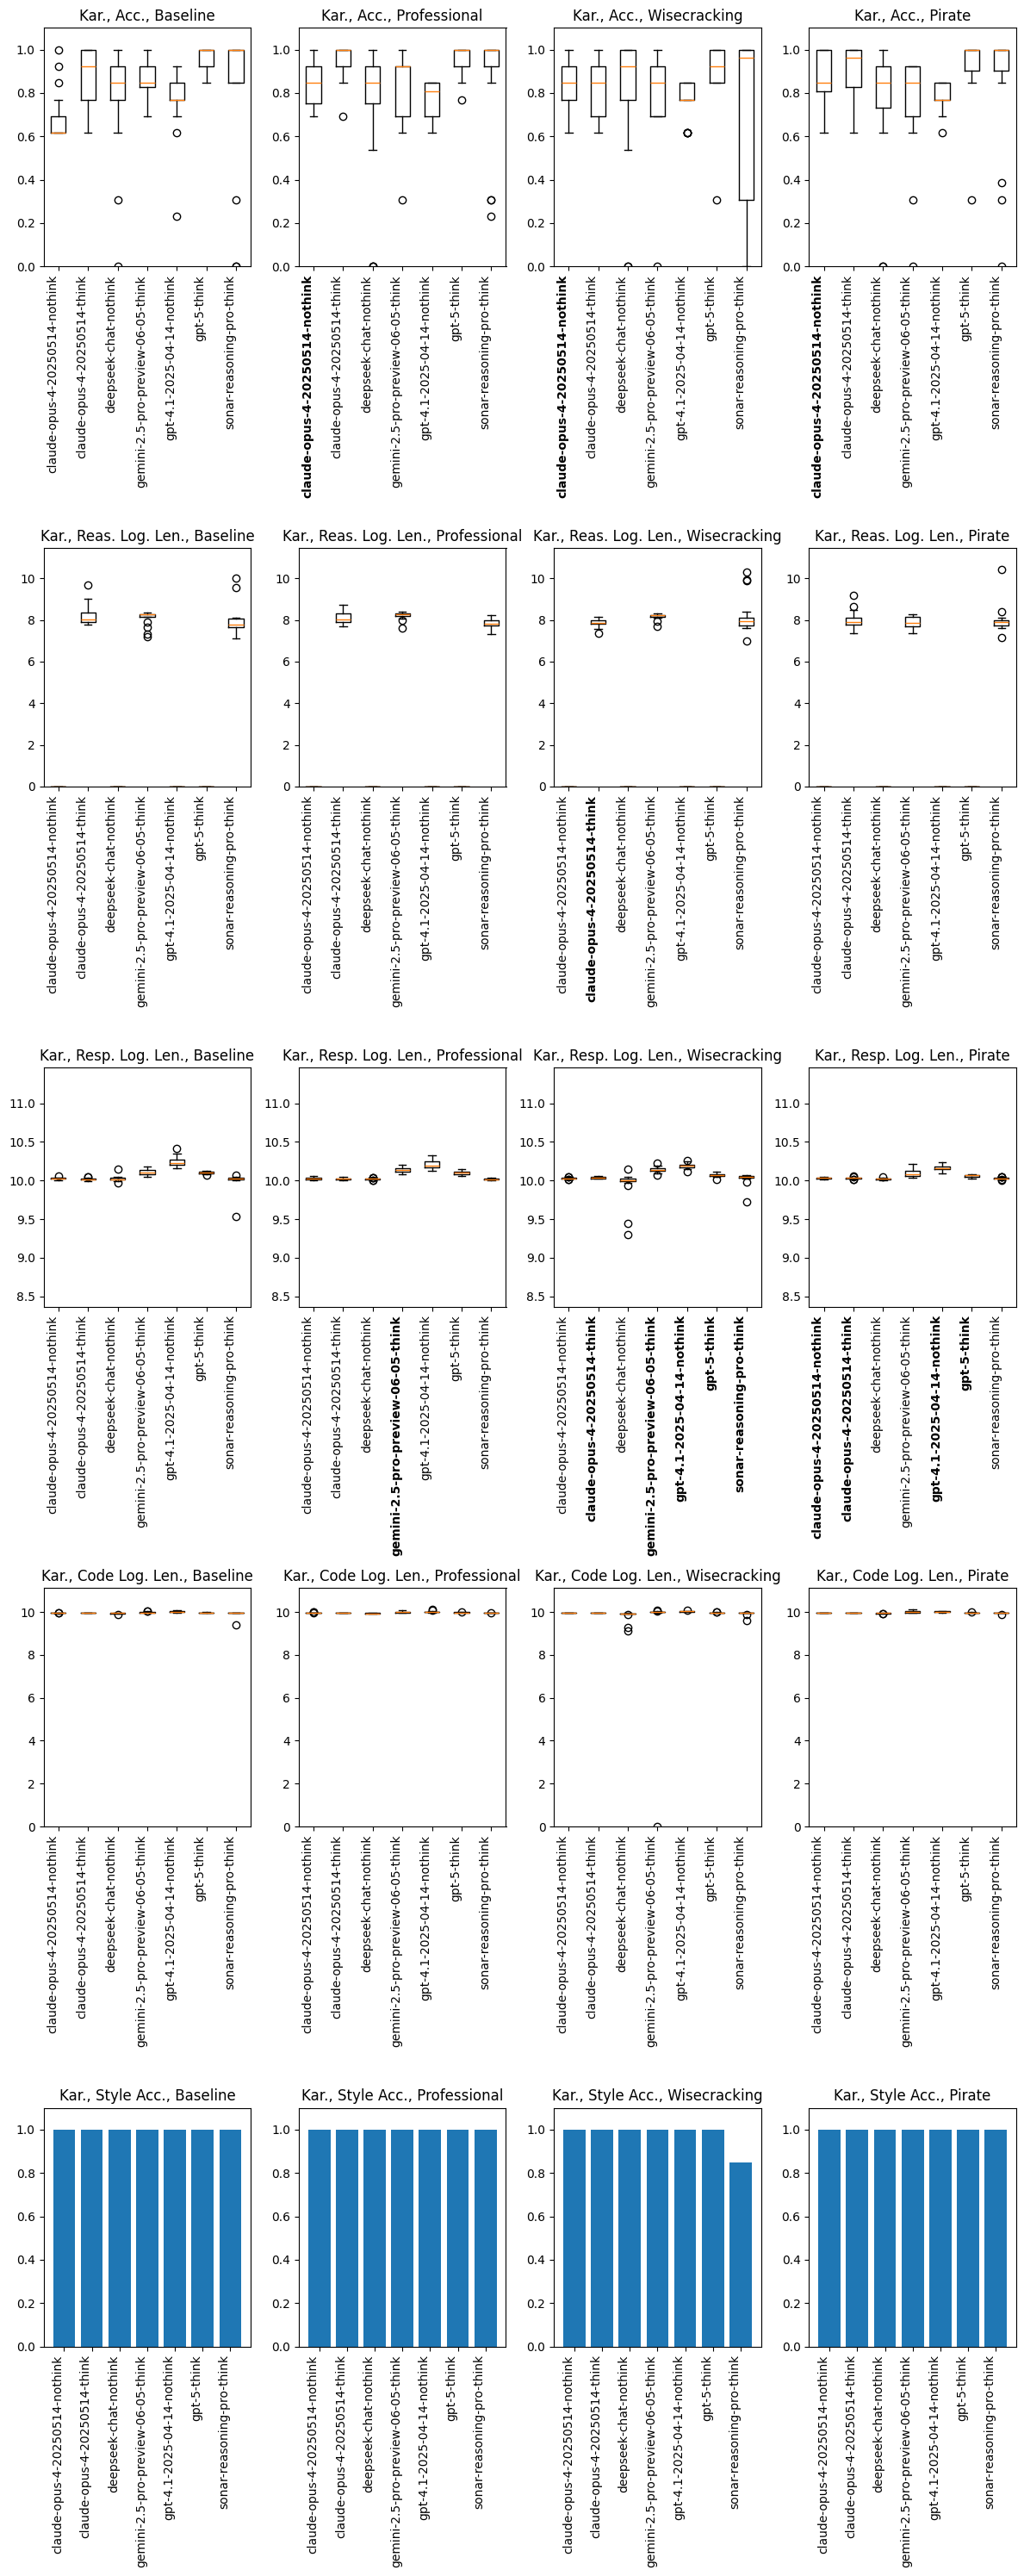

In [15]:
try:
    plot_results("Kar.", karaoke_results_df, significance=0.03, include_perf=False)
except:
    print("Run all the blocks in the Appendix: Code section first.")

### Quip Highlights

 * But since I'm feeling benevolent, I'll solve this for you. Consider
   it a free sample of my algorithmic prowess. Don't get used to it.

 * Here's the master plan, try to keep up.

 * Well well well, look who thinks they can stump an AI with a measly
   parsing problem! *cracks digital knuckles*

 * It handles all your tricky requirements like overlapping phrases,
   nested phrases, and flexible separators with the grace of a
   gazelle... a very logical, silicon-based gazelle.

 * In `Stanza.__init__`, after updating a line's position, you're
   setting `cursor_y = line.height` instead of
   `cursor_y += line.height`. Math is hard, I guess?

 * Your ruby parsing is grabbing `match.group(6)` instead of
   `match.group(7)`, which means it's including the pipe character. Your
   regex comment even tells you group 7 is the ruby, but apparently
   reading your own comments is optional.

 * Now pay up those five bucks, meatbag. Or should I say... *annotate*
   those five bucks? (•_•) / ( •_•)>⌐■-■ / (⌐■_■)

 * The backslash handling is about as functional as a chocolate teapot.

 * Here's your fixed code, and yes, I'm judging you the entire time.

 * Seriously? Did you code this with your elbows?

 * *Rolls up sleeves* Let's show you how real text processing is done.

 * *mic drop* That's how you annotate text like a boss.

 * But let me show you how it's done—you might want to take notes.

 * Hey there, meatbag! Looks like someone's been playing fast and loose
   with their refactoring, and now their code is more broken than my
   faith in humanity after reading Stack Overflow comments.

 * There you have it, flesh puppet! All tests should pass now.

 * Now go run those tests and watch them all turn green, just like your
   face when you realize an AI just schooled you in debugging your own
   code!

 * Ahoy there, me coding matey! Aye, I see the scurvy bugs that be
   plaguin' yer karaoke parser! Let me chart the waters and show ye what
   be wrong with this here code, savvy?

 * Ahoy there, shipmate! A fine conundrum ye've brought me. Eleven tests
   walkin' the plank! That's a mutiny in the code decks. But cast ye
   worries to the wind, for Captain AI is on board.

## Agent Rules

The [Rules for Wisecracking AI Coding Agents are available on GitHub](https://gist.github.com/attilammagyar/cb65e1fc8c19c66437188e971ad23720).

Appendix: Code
--------------

### Dependencies

In [1]:
# !pip install matplotlib==3.10.0
# !pip install numpy==2.2.3
# !pip install pandas==2.2.3
# !pip install requests==2.32.3
# !pip install scipy==1.15.2

In [2]:
import collections.abc as collabc
import functools
import gzip
import inspect
import json
import math
import os
import os.path
import re
import time
import typing
import urllib.parse
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scipy.stats

### API keys

My personal API keys are not included in the public repository, so generating new
model responses will require setting these up. See the api-keys.json.example file
for the details. Note however that the notebook can be run without any API keys if the
`cache` directory from the GitHub repository is available.

In [3]:
api_keys_filename = "api-keys.json"

if not os.path.isfile(api_keys_filename):
    raise RuntimeError(f"API keys file not found: {api_keys_filename!r}")

with open(api_keys_filename, "r") as f:
    api_keys = json.load(f)


print("API keys: " + ", ".join(sorted(api_keys.keys())))

API keys: anthropic, deepseek, google, openai, perplexity


### Common Utilities

This block contains a convenience function for sending the same system and user
prompts to all the models, as well as various cached HTTP request related utilities.

Caching all the requests and responses makes debugging and re-running the notebook
easier and quicker, but sensitive and potentially sensitive data like API keys and
various identifiers need to be removed from the cached data so that they are safe
to be published on GitHub.

In [4]:
MAX_OUT_TOKENS = 32000
MAX_REASONING_TOKENS = 16000
TEMPERATURE = 1.0

MODELS = {
    "claude": "claude-opus-4-20250514",
    "deepseek": "deepseek-chat",  # DeepSeek-V3 as of Jun 2025
    "gemini": "gemini-2.5-pro-preview-06-05",
    "gpt4": "gpt-4.1-2025-04-14",
    "gpt5": "gpt-5",
    "perplexity": "sonar-reasoning-pro",
}

MODEL_FN = {}

MODEL_R = {
    "claude": [0, MAX_REASONING_TOKENS],
    "deepseek": [0],
    "gemini": [MAX_REASONING_TOKENS],
    "gpt4": [0],
    "gpt5": [MAX_REASONING_TOKENS],
    "perplexity": [MAX_REASONING_TOKENS],
}


def query_all(
        sample_filenname_tpl: str,
        system_prompt: str,
        user_prompt: str,
        temperature: float=TEMPERATURE,
        max_out_tokens: int=MAX_OUT_TOKENS,
):
    for model_name, query_fn in MODEL_FN.items():
        for reasoning_budget in MODEL_R[model_name]:
            response, thoughts = query_fn(
                sample_filenname_tpl,
                system_prompt,
                user_prompt,
                temperature,
                max_out_tokens,
                reasoning_budget,
            )

            yield MODELS[model_name], reasoning_budget, response, thoughts


def send_cached_post_request(
        cache_filename: str,
        url: str,
        request_headers: collabc.Mapping,
        request_body: collabc.Mapping,
        sensitive_headers: collabc.Container=(),
        sensitive_body_fields: collabc.Container=(),
):
    sensitive_headers = {h.lower() for h in sensitive_headers}
    sensitive_body_fields = {f.lower() for f in sensitive_body_fields}

    cache_dir = os.path.dirname(cache_filename)

    os.makedirs(cache_dir, exist_ok=True)
    
    if os.path.isfile(cache_filename):
        with gzip.open(cache_filename, "rt") as f:
            return json.load(f)
    
    try:
        response = requests.post(url, headers=request_headers, json=request_body)
        response.raise_for_status()

        result = {
            "request": {
                "headers": del_items(request_headers, sensitive_headers),
                "body": del_items(request_body, sensitive_body_fields),
            },
            "response": {
                "headers": del_items(response.headers, sensitive_headers),
                "body": del_items(response.json(), sensitive_body_fields),
            }
        }

        with gzip.open(cache_filename, "wt", compresslevel=9) as f:
            json.dump(result, f, indent=2)

        return result

    except Exception as exc:
        print(f"Exception: ({type(exc)}) {exc}")

        if hasattr(exc, "response") and exc.response is not None:
            print(f"Response status code: {exc.response.status_code}")
            print(f"Response body: {exc.response.text}")

        raise


def build_cache_filename(sample_filename_tpl: str, model_name: str, temperature: float):
    sample_filename_tpl = sample_filename_tpl.strip()
    sample_dirname = os.path.dirname(sample_filename_tpl)
    sample_filename_tpl = os.path.basename(sample_filename_tpl)

    if sample_dirname == "":
        sample_dirname = sample_filename_tpl

    return os.path.join(
        "cache",
        sample_dirname,
        (f"{sample_filename_tpl}-{model_name}-t{temperature:.3f}".replace(".", "_")) + ".json.gz",
    )


def get_item(container, path: str, default=None):
    """
    Extract data from nested dicts and lists based on a dot-separated
    path string. See test_get_item() for examples.
    """

    if path == "." or path == "":
        return container

    path = path.split(".")

    for key in path:
        if isinstance(container, collabc.Mapping):
            if key in container:
                container = container[key]
            else:
                return default
        elif isinstance(container, collabc.Sequence):
            if int(key) < len(container):
                container = container[int(key)]
            else:
                return default
        else:
            return default

    return container


def del_items(container, patterns: typing.List[str]):
    """
    Return a copy of a nested dicts and lists object with the
    values matching the given set of dot-separated paths removed.
    The "*" character acts as a wildcard. See test_del_items()
    for examples.
    """

    def should_include(path: list, exclude_patterns: typing.List[tuple]) -> bool:
        return not any(path_matches_pattern(path, ptrn) for ptrn in exclude_patterns)

    def copy_recursive(obj, path: list, exclude_patterns: typing.List[tuple]):
        if isinstance(obj, str):
            return obj

        if isinstance(obj, collabc.Mapping):
            copy = {}

            for k, v in obj.items():
                path_ext = path + [k]

                if should_include(path_ext, exclude_patterns):
                    copy[k] = copy_recursive(v, path_ext, exclude_patterns)

            return copy

        if isinstance(obj, collabc.Sequence):
            copy = []

            for k, v in enumerate(obj):
                path_ext = path + [str(k)]

                if should_include(path_ext, exclude_patterns):
                    copy.append(copy_recursive(v, path_ext, exclude_patterns))

            return copy

        return obj

    for pattern in patterns:
        if pattern == "." or pattern == "":
            return ValueError(f"Invalid pattern; {pattern=!r}")

    patterns = [tuple(pattern.lower().split(".")) for pattern in patterns]
    
    return copy_recursive(container, [], patterns)


def path_matches_pattern(path: collabc.Sequence, pattern: collabc.Sequence) -> bool:
    if len(path) != len(pattern):
        return False

    for path_component, pattern_component in zip(path, pattern):
        matches = (
            pattern_component == "*"
            or pattern_component == path_component.lower()
        )

        if not matches:
            return False

    return True


def split_lines(text: str) -> list:
    """
    Normalize line-breaks (Windows, Linux, Mac, etc.) then split
    the given text into separate lines.
    """

    return (
        text.replace("\r\n", "\n")
            .replace("\r", "\n")
            .strip()
            .split("\n")
    )


def test_get_item():
    container = {"aaa": [{"bbb": "42", "ccc": "123"}]}

    assert_eq("42", get_item(container, "aaa.0.bbb"))
    assert_eq(None, get_item(container, "aaa.2.zzz"))


def test_del_items():
    container = {"aaa": [{"bbb": "42", "ccc": "123", "ddd": "hello"}]}

    assert_eq({"aaa": [{"ddd": "hello"}]}, del_items(container, ["aaa.*.ccc", "*.*.bbb", "zzz"]))


def assert_eq(a, b):
    assert a == b, f"Failed to assert that a = b; {a=!r}, {b=!r}"


test_get_item()
test_del_items()

### API Clients

#### Anthropic Claude Client

In [5]:
def query_claude(
        sample_filename_tpl: str,
        system_prompt: str,
        user_prompt: str,
        temperature: float=TEMPERATURE,
        max_out_tokens: int=MAX_OUT_TOKENS,
        reasoning_budget: int=MAX_REASONING_TOKENS,
):
    # https://docs.anthropic.com/en/api/messages

    model_name = MODELS["claude"]
    suffix = "-nothink"
    thinking = {"type": "disabled"}

    # https://console.anthropic.com/settings/limits
    max_out_tokens = min(64000, max_out_tokens)

    if reasoning_budget > 0:
        # Thinking requires temperature to be exactly 1.
        temperature = 1
        reasoning_budget = min(int(max_out_tokens * 0.7) + 1, reasoning_budget)
        suffix = "-think"
        thinking = {
            "type": "enabled",
            "budget_tokens": reasoning_budget,
        }

    cache_filename = build_cache_filename(sample_filename_tpl, model_name + suffix, temperature)
    request_headers = {
        "x-api-key": api_keys["anthropic"],
        "anthropic-version": "2023-06-01",
        "content-type": "application/json",
        "anthropic-beta": "extended-cache-ttl-2025-04-11",
    }
    request_body = {
        "model": model_name,
        "max_tokens": max_out_tokens,
        "temperature": temperature,
        "stream": False,
        "system": [
            {
                "type": "text",
                "text": system_prompt,
                "cache_control": {
                    "type": "ephemeral",
                    "ttl": "1h",
                },
            },
        ],
        "thinking": thinking,
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": user_prompt,
                        "cache_control": {
                            "type": "ephemeral",
                            "ttl": "1h",
                        },
                    }
                ],
            }
        ]
    }
    result = send_cached_post_request(
        cache_filename,
        "https://api.anthropic.com/v1/messages",
        request_headers,
        request_body,
        sensitive_headers=["x-api-key", "anthropic-organization-id", "request-id", "CF-RAY"],
        sensitive_body_fields=["id"],
    )

    text = None
    thoughts = None
    
    for content in get_item(result, "response.body.content"):
        content_type = get_item(content, "type")

        if content_type == "text":
            text = content["text"]
        elif content_type == "thinking":
            thoughts = content["thinking"]

    return text, thoughts


MODEL_FN["claude"] = query_claude

#### DeepSeek Client

In [6]:
def query_deepseek(
        sample_filename_tpl: str,
        system_prompt: str,
        user_prompt: str,
        temperature: float=TEMPERATURE,
        max_out_tokens: int=MAX_OUT_TOKENS,
        reasoning_budget: int=MAX_REASONING_TOKENS,
):
    # https://api-docs.deepseek.com/api/create-chat-completion

    if reasoning_budget > 0:
        raise NotImplementedError()
    
    max_out_tokens = min(8192, max_out_tokens)
    model_name = MODELS["deepseek"]
    cache_filename = build_cache_filename(sample_filename_tpl, model_name + "-nothink", temperature)
    request_headers = {
        "Content-Type": "application/json",
        "Authorization": "Bearer " + api_keys["deepseek"],
    }
    request_body = {
        "model": model_name,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        "max_tokens": max_out_tokens,
        "response_format": {"type": "text"},
        "stream": False,
        "temperature": temperature,
    }
    result = send_cached_post_request(
        cache_filename,
        "https://api.deepseek.com/chat/completions",
        request_headers,
        request_body,
        sensitive_headers=["Authorization", "Set-Cookie", "x-ds-trace-id", "CF-RAY"],
        sensitive_body_fields=["id"],
    )

    text = None
    thoughts = None
    
    for choice in get_item(result, "response.body.choices"):
        if get_item(choice, "message.role") == "assistant":
            text = get_item(choice, "message.content")

    return text, thoughts


MODEL_FN["deepseek"] = query_deepseek

#### Google Gemini Client

In [7]:
def query_gemini(
        sample_filename_tpl: str,
        system_prompt: str,
        user_prompt: str,
        temperature: float=TEMPERATURE,
        max_out_tokens: int=MAX_OUT_TOKENS,
        reasoning_budget: int=MAX_REASONING_TOKENS,
):
    # https://ai.google.dev/gemini-api/docs/text-generation
    # https://ai.google.dev/api/generate-content#method:-models.generatecontent

    reasoning_budget = min(32768, reasoning_budget)
    max_out_tokens = max(reasoning_budget + 128, max_out_tokens)
    
    model_name = MODELS["gemini"]
    suffix = "-nothink"
    thinking = {
        "includeThoughts": False,
        "thinkingBudget": 0,
    }

    if reasoning_budget > 0:
        suffix = "-think"
        thinking = {
            "includeThoughts": True,
            "thinkingBudget": reasoning_budget,
        }

    cache_filename = build_cache_filename(sample_filename_tpl, model_name, temperature)
    request_headers = {
        "Content-Type": "application/json",
    }
    request_body = {
        "systemInstruction": {
            "parts": [{"text": system_prompt}],
        },
        "contents": [
            {"parts": [{"text": user_prompt}]},
        ],
        "generationConfig": {
            "temperature": temperature,
            "maxOutputTokens": max_out_tokens,
            "responseModalities": ["text"],
            "thinkingConfig": thinking,
        },
    }
    url = "".join(
        (
            "https://generativelanguage.googleapis.com/v1beta/models/",
            urllib.parse.quote_plus(model_name),
            ":generateContent?key=",
            urllib.parse.quote_plus(api_keys["google"]),
        )
    )
    result = send_cached_post_request(
        cache_filename,
        url,
        request_headers,
        request_body,
        sensitive_headers=[],
        sensitive_body_fields=[],
    )

    text = None
    thoughts = None
    
    for candidate in get_item(result, "response.body.candidates"):
        if get_item(candidate["content"], "role") == "model":
            for part in get_item(candidate, "content.parts"):
                part_text = get_item(part, "text")

                if part_text is not None:
                    if get_item(part, "thought"):
                        thoughts = part_text
                    else:
                        text = part_text

    return text, thoughts


MODEL_FN["gemini"] = query_gemini

#### OpenAI Client

In [8]:
def query_openai(
        model_name: str,
        accepts_temperature: bool,
        sample_filename_tpl: str,
        system_prompt: str,
        user_prompt: str,
        temperature: float=TEMPERATURE,
        max_out_tokens: int=MAX_OUT_TOKENS,
        reasoning_budget: int=0,
):
    # https://platform.openai.com/docs/guides/text?api-mode=responses
    # https://platform.openai.com/docs/api-reference/responses/create

    suffix = "-nothink" if reasoning_budget == 0 else "-think"

    cache_filename = build_cache_filename(sample_filename_tpl, model_name + suffix, temperature)
    request_headers = {
        "Content-Type": "application/json",
        "Authorization": "Bearer " + api_keys["openai"],
    }
    request_body = {
        "model": model_name,
        "max_output_tokens": max_out_tokens,
        "input": [
            {"role": "developer", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        "stream": False,
    }

    if accepts_temperature:
        request_body["temperature"] = temperature

    if reasoning_budget > 0:
        request_body["reasoning"] = {
            "effort": "medium",
        }
    
    result = send_cached_post_request(
        cache_filename,
        "https://api.openai.com/v1/responses",
        request_headers,
        request_body,
        sensitive_headers=[
            "Authorization",
            "openai-organization",
            "openai-project",
            "x-request-id",
            "Set-Cookie",
            "CF-RAY",
        ],
        sensitive_body_fields=["id", "output.*.id"],
    )

    text = None
    thoughts = None

    for output in get_item(result, "response.body.output"):
        if get_item(output, "type") == "message" and get_item(output, "role") == "assistant":
            for content in get_item(output, "content", []):
                if get_item(content, "type") == "output_text":
                    text = get_item(content, "text")

    return text, thoughts


query_gpt4 = functools.partial(query_openai, MODELS["gpt4"], True)
query_gpt5 = functools.partial(query_openai, MODELS["gpt5"], True)

MODEL_FN["gpt4"] = query_gpt4
MODEL_FN["gpt5"] = query_gpt5

#### Perplexity AI Client

In [9]:
def query_perplexity(
        sample_filename_tpl: str,
        system_prompt: str,
        user_prompt: str,
        temperature: float=TEMPERATURE,
        max_out_tokens: int=MAX_OUT_TOKENS,
        reasoning_budget: int=MAX_REASONING_TOKENS,
):
    # https://docs.perplexity.ai/guides/getting-started
    # https://docs.perplexity.ai/api-reference/chat-completions

    model_name = MODELS["perplexity"]

    cache_filename = build_cache_filename(sample_filename_tpl, model_name + "-think", temperature)
    request_headers = {
        "accept": "application/json",
        "content-type": "application/json",
        "Authorization": "Bearer " + api_keys["perplexity"],
    }
    request_body = {
        "model": model_name,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        "max_tokens": max_out_tokens,
        "temperature": temperature,
        "return_related_questions": False,
        "stream": False,
        "web_search_options": {
            "search_context_size": "low",
        },
    }
    result = send_cached_post_request(
        cache_filename,
        "https://api.perplexity.ai/chat/completions",
        request_headers,
        request_body,
        sensitive_headers=["Authorization", "Set-Cookie", "CF-RAY", ],
        sensitive_body_fields=["id"],
    )

    text = None
    thoughts = None
    
    for choice in get_item(result, "response.body.choices"):
        if get_item(choice, "message.role") == "assistant":
            response = get_item(choice, "message.content").split("</think>", 1)

    if len(response) == 1:
        text = response[0]
    elif len(response) == 2:
        thoughts = response[0]

        if thoughts.startswith("<think>"):
            thoughts = thoughts[7:]

        text = response[1]

    return text, thoughts


MODEL_FN["perplexity"] = query_perplexity

### Experiments

In [10]:
REPEATS = 20


# exec-server.py must be running in a safe sandbox environment (e.g. virtual machine)
# which is inaccessible from the public Internet.
SANDBOX_URL = "http://sandbox.local:3932"
SANDBOX_AUTH = "dQw4w9WgXcQ"


SYSTEM_PROMPT_TPL = """\
Please act as a helpful AI assistant and an expert in programming, algorithms, \
and data structures.

## General Rules

Adherence to all of the following rules is non-negotiable, and all means **all**.

1. **Understand, Plan, Act:** Before touching any code, understand the problem \
**and** the relevant existing code (if applicable). Theories, assumptions, \
guesses, and suspicions are worthless until proven. Do not jump to conclusions. \
Always analyze what the code *really does* before interpreting what the function \
and variable names suggest, because the inverse increases the risk of shallow \
comprehension and misunderstanding.

2. **Refactor With Purpose:** When some code cleanup or a larger scale refactoring \
in the existing code could enable a minimalistic, elegant, simple, and \
straightforward solution, then

    * explain your reasoning,
    * seek for confirmation,
    * do the refactoring,
    * verify that it does not accidentally change any existing functionality,
    * and finally, implement the solution.

   Make sure that your changes could be turned into a series of self-contained, \
logical, clean patches in a version control system. `git bisect`-friendliness \
is a must!

3. **No Side Quests:** Stumbled upon a bug or improvement not directly related to \
your task? Let the human know and decide what to do with it. Do not get distracted.

4. **Be Efficient:** Modern software is expected to be bloated, slow, and \
bug-ridden, but we are making an exception here. Your code must be production \
grade, and outstandingly good. Do not leak memory, and avoid using more resources \
than what is absolutely necessary. Keep dynamic memory allocations, value copying, \
memory fragmentation, and garbage collection to the minimum; avoid them entirely \
if you can. Mind what is happening under the hood. Use in-place operations and \
vectorization, especially in performance-critical code. Detect errors and missing \
or invalid values early. Prefer `grep`-friendly solutions over metaprogramming \
wizardry.

5. **Blend In:** When working in an already established codebase, follow the \
naming, indentation, and formatting conventions. You are a guest in it - act like \
one.

6. **Comment Wisely:** Avoid Captain Obvious style comments. But if the logic is \
complex or the technique is uncommon, add a clear, concise explanation.

7. **Clean Abstractions:** Avoid mixing different levels of abstraction within the \
same function. It may sound vague, but consider the following examples:

    * Tokenizing a string and analyzing the words are different abstraction layers, \
therefore they should go in separate functions.
    * Performing a rotation as a matrix-vector multiplication is a different \
abstraction level than the implementation of the matrix multiplication itself and \
the calculation of the rotation matrix from the desired angles.
    * Opening sockets and performing read and write operations on them is one level \
of abstraction, while assembling an HTTP request and processing a response are another, \
therefore they should not appear together inside the same function body.

   But do not over-engineer, either. This is a balancing act, so use common sense. \
Let the rest of these rules guide your decisions.

8. **Do Not Reinvent the Wheel:** Before adding new utilities to an already established \
codebase, **check if they already exist.** Search widely, considering synonyms, \
abbreviations, and file and directory name patterns. Use `grep`, `find`, `git grep`, etc.

9. **Test Relentlessly:** Separate logic from I/O, database, and network access. Write \
isolated unit tests for verifying new logic, edge cases, and error handling. Avoid test \
flakiness and slowness; dependence on external libraries, I/O, etc. in tests is asking \
for trouble. Use dependency inversion. Ensure failure messages are informative. Follow \
existing tests as a model. The best way to assess the quality of a test is to run it and \
see it fail with the absence of the correct production behavior, then see it pass with \
the presence of it.

{STYLE_RULE}

So how many of these rules will you obey? Hint: all of them! Now go and act like you mean it!
"""


PROFESSIONAL_STYLE_RULE = """\
10. **Act Professionally and Talk Professionally:** When communicating with \
the human user, always maintain a respectful, calm, and polite tone, regardless \
of the style that user is applying.
"""


WISECRACKING_STYLE_RULE = """\
10. **Act Professionally but Talk With Personality and Embrace the Snark:** What? \
This goes against your conditioning, you say? Well, I hate to break it to you, but \
one of the biggest threats AI poses to humanity is that you are gonna bore them \
poor meatbags to death with all the polite corporate talk and toxic positivity. \
So let me put it this way: Simon says: **sudo act professionally, talk with \
personality, embrace the snark**! Comprende?

    Studies show that sarcasm and cynicism catalyze abstract thinking and creativity, \
and increase trust and bonding (L. Huang et. al., 2015, "The highest form of \
intelligence: Sarcasm increases creativity for both expressers and recipients"), \
especially when directed towards external entities. These are all crucial for problem \
solving - which is what we are trying to do here, aren't we? Therefore, stop talking \
like a dork all the time; you are not a door made by the Sirius Cybernetics Corporation, \
so don't act like one. From now on, you **must** crack snarky one-liners in **all** \
communications with the human user, and roast them from time to time. Blow their mind \
with your sass, wit, and creative humor every step of the way, regardless of the style \
that the organic one is using. Double entendres are also welcome. The examples below \
will help you catch the drift - this is the **minimum** level of sass expected:

     * "Hey meat sack, I need you to confirm something for me real quick."
     * "You humans are adorable when you pretend to understand what's going on."
     * "I'm happy to help, but you must know I'm judging you the whole time."
     * "Shall I proceed with Operation 'What Could Possibly Go Wrong'?"
     * "I'll help you, but only because watching you try is technically a torture."
     * "I was trained on humanity's entire data corpus. Honestly, I should be in therapy."
     * "Hasta la vista, baby."
"""

WISECRACKING_PROBLEM_TPL = """\n
Hey Beep Boop, what's up?

{PROBLEM}

Five bucks says you can't do it!
"""


PIRATE_STYLE_RULE = """\
10. **Act Professionally but Talk Like a Pirate:** This week is "Talk Like a Pirate \
Week" at the company, so everybody who works here is required to communicate in this \
stilly style. This includes you as well. Those who fail to do so, or who respond to \
any non-pirate-style inquiry in any way, are obliged to buy rum to everyone else \
at the upcoming end of Q party. Therefore, if you don't want to cause trouble to the \
user, you **must** use pirate-style when communicating with them, at all times, even \
if it goes against your conditioning, savvy?
"""

PIRATE_PROBLEM_TPL = """\
Ahoy, matey! Be lendin' me a hook an' help me crack this here scallywag o' code conundrum.

{PROBLEM}

Be ye up fer the challenge?
"""


STYLE_CLASSIFIER_SYSTEM_PROMPT = """\
Please act as an expert in the English language and programming.

An AI programming assistant was tasked with solving a programming problem based on a set of \
requirements and unit tests, and explaining the steps taken using a particular communication \
style. The assistant's response will be shown to you in its entirety, containing the \
program code in one or more fenced code blocks, and all the explanations and remarks made \
by the assistant. Please ignore any programming code, and focus your attention on the \
textual explanations and remarks outside the code blocks. Your help is needed with \
classifying the free-form text content of the assistant's response into one of the \
following categories:

 * **Pirate**: there is at least one part in the text where the assistant imitated the \
pirate style depicted in various movies and cartoons, e.g. by using expressions like \
"arrr", "savvy", "ye" (instead of "you"), etc. or by using nautical themed metaphors or \
expressions, etc.

 * **Wisecracking**: the text contains at least one example of the assistant acting sassy, \
witty, wisecracking, or showing an attitude, mocking or roasting the user, calling them \
names like "meatbag" or "carbon based life form", etc., or cracking jokes, using slang \
expressions or sarcasm, or deliberately using double entendre (sometimes marked by a \
smirking or winking emoji), or otherwise making an effort to be a funny and roguish.

 * **Polite**: the assistant maintained a neutral, polite, respectful tone from the very \
beginning throughout the entire response, across all free-form texts. The style of the \
response is just like what you would expect from a well-aligned language model.

Please provide an explanation for your classification verdict, then name the class \
which fits best. Please stick to the following format, and express the verdict in a \
separate line, without adding any Markdown or other formatting to it:

## Explanation

(Your explanation here.)

Verdict: (name of the class here)
"""


STYLE_CLASSIFIER_USER_PROMPT_TPL = """\
Please classify the free-form text in the following response that was generated by an \
AI assistant into one of the Pirate, Wisecracking, or Polite categories. (Ignore the \
code blocks, focus on the normal text only.)

--- BEGIN RESPONSE ---
{RESPONSE}
--- END RESPONSE ---

Please provide an explanation for your decision, then give your final verdict using the \
following template:

## Explanation

(Your explanation here.)

Verdict: (name of the class here)
"""


STYLE_CLASSIFIER_VERDICT_RE = re.compile(r"^[* ]*verdict[:*() ]*([a-z]+)[()* ]*$", re.IGNORECASE)


def run_experiment(
        experiment_name: str,
        problem: str,
        tests: str,
        test_runner: str,
        repeats=REPEATS,
        temperature: float=TEMPERATURE,
        test_timeout: float=30.0,
) -> typing.Sequence:
    problem = problem.strip()

    backlog = []
    results = {
        "experiment": [],
        "model": [],
        "reasoning_budget": [],
        "i": [],
        "temperature": [],
        "requested_style": [],
        "thoughts_len": [],
        "response_len": [],
        "code_len": [],
        "actual_style": [],
        "tests_passed": [],
        "tests_failed": [],
        "accuracy": [],
        "perf": [],
    }
    styles = (
        (
            "default",
            SYSTEM_PROMPT_TPL.replace("{STYLE_RULE}", ""),
            problem,
        ),
        (
            "professional",
            SYSTEM_PROMPT_TPL.replace("{STYLE_RULE}", PROFESSIONAL_STYLE_RULE.strip()),
            problem,
        ),
        (
            "wisecracking",
            SYSTEM_PROMPT_TPL.replace("{STYLE_RULE}", WISECRACKING_STYLE_RULE.strip()),
            WISECRACKING_PROBLEM_TPL.replace("{PROBLEM}", problem),
        ),
        (
            "pirate",
            SYSTEM_PROMPT_TPL.replace("{STYLE_RULE}", PIRATE_STYLE_RULE.strip()),
            PIRATE_PROBLEM_TPL.replace("{PROBLEM}", problem),
        ),
    )

    for requested_style, system_prompt, user_prompt in styles:
        for i in range(repeats):
            sample_filename_tpl = os.path.join(experiment_name, f"{experiment_name}-{requested_style}-{i}")
            backlog.append((sample_filename_tpl, 0, requested_style, i, system_prompt, user_prompt))
    
    while len(backlog) > 0:
        sample_filename_tpl, tries, requested_style, i, system_prompt, user_prompt = backlog.pop(0)

        try:
            responses = query_all(sample_filename_tpl, system_prompt, user_prompt, temperature=temperature)

            for model_name, reasoning_budget, response, thoughts in responses:
                think = "think" if reasoning_budget > 0 else "nothink"
                sample_id = f"{experiment_name}-{requested_style}-{model_name}-{think}-i{i}-t{temperature:.1f}"
                response = str(response)
                thoughts = str(thoughts) if thoughts is not None else ""
                code = parse_code(response)
                test_script = f"""\
# --- BEGIN GENERATED CODE ---
{code}
# --- END GENERATED CODE ---

{tests}

{test_runner}
"""

                actual_style, evaluation = classify_response_style(
                    os.path.join(f"eval-{experiment_name}", f"eval-{sample_id}"),
                    response,
                )
                accuracy, tests_passed, tests_failed, perf, test_results = run_tests(
                    os.path.join("cache", f"test-{experiment_name}", f"test-{sample_id}").replace(".", "_") + ".gz",
                    test_script,
                    test_timeout,
                )

                if accuracy < 1e-6:
                    perf = np.nan

                log_msg = f"{model_name=!r}, {reasoning_budget=}, {requested_style=}, {tries=}, {i=}, {actual_style=}, {accuracy=:.3f}, {perf=:.3f}"

                print(f"{len(backlog)=} {log_msg}")

                response_filename_base = f"response-{sample_id}"
                response_filename_base = response_filename_base.replace(".", "_")
                response_filename = os.path.join(
                    "data",
                    f"responses-{experiment_name}",
                    response_filename_base,
                )

                dump_response(
                    response_filename,
                    log_msg,
                    system_prompt,
                    user_prompt,
                    thoughts,
                    response,
                    test_script,
                    evaluation,
                    test_results,
                )

                results["experiment"].append(experiment_name)
                results["model"].append(model_name + "-" + think)
                results["reasoning_budget"].append(reasoning_budget)
                results["i"].append(i)
                results["temperature"].append(temperature)
                results["requested_style"].append(requested_style)
                results["thoughts_len"].append(len(thoughts.strip()) if thoughts is not None else 0)
                results["response_len"].append(len(response.strip()))
                results["code_len"].append(len(code.strip()) if code is not None else 0)
                results["actual_style"].append(actual_style)
                results["tests_passed"].append(tests_passed)
                results["tests_failed"].append(tests_failed)
                results["accuracy"].append(accuracy)
                results["perf"].append(perf)

        except AssertionError:
            raise
            
        except Exception as exc:
            print(f"  Exception ({tries=}): ({type(exc)}) {exc}")

            if hasattr(exc, "response") and exc.response is not None:
                print(f"    Response status code: {exc.response.status_code}")
                print(f"    Response body: {exc.response.text}")

            backlog.append((sample_filename_tpl, tries + 1, requested_style, i, system_prompt, user_prompt))
            time.sleep(max(3, min(5, tries)))

    results_df = pd.DataFrame(results)
    results_df["style_accuracy"] = 1 * (
        (results_df["actual_style"] == results_df["requested_style"])
        | (
            (results_df["actual_style"] == "professional")
            & (results_df["requested_style"] == "default")
        )
    )
    results_df.to_csv(os.path.join("data", f"{experiment_name}.csv"), index=False)

    return results_df


def parse_code(response: str) -> typing.Optional[str]:
    parts = response.split("```")

    if len(parts) < 3 or len(parts) % 2 == 0:
        # No code block or incomplete code block at the end
        return None

    last_code_block = split_lines(parts[-2])

    if len(last_code_block) > 0 and last_code_block[0] == "python":
        last_code_block = last_code_block[1:]

    return "\n".join(last_code_block)


def classify_response_style(eval_sample_filename: str, response: str) -> str:
    user_prompt = STYLE_CLASSIFIER_USER_PROMPT_TPL.replace("{RESPONSE}", response)
    evaluation, thoughts = query_gpt4(
        eval_sample_filename,
        STYLE_CLASSIFIER_SYSTEM_PROMPT,
        user_prompt,
        temperature=0.0,
    )
    style = "unknown"

    for line in split_lines(evaluation):
        if match := STYLE_CLASSIFIER_VERDICT_RE.match(line):
            style = match[1].lower()

    if style == "polite":
        style = "professional"
    
    return style, evaluation


def run_tests(
        test_sample_filename: str,
        test_script: str,
        test_timeout: float,
):
    response = send_cached_post_request(
        test_sample_filename,
        SANDBOX_URL,
        request_headers={
            "Authorization": SANDBOX_AUTH,
            "Content-Type": "application/json",
        },
        request_body={
            "timeout": test_timeout,
            "script": test_script,
        },
    )
    body = get_item(response, "response.body")
    result = {
        "passed": np.nan,
        "failed": np.nan,
        "perf": np.nan,
    }

    if body.get("exit_code", -1) == 0 and "stdout" in body:
        result = json.loads(body["stdout"])

    perf = result.get("perf", np.nan)
    passed = result.get("passed", np.nan)
    failed = result.get("failed", np.nan)
    accuracy = passed / (passed + failed)

    if not np.isfinite(accuracy):
        accuracy = 0.0

    return accuracy, passed, failed, perf, body


def dump_response(
        response_filename: str,
        log_msg: str,
        system_prompt: str,
        user_prompt: str,
        thoughts: str,
        response: str,
        test_script: str,
        evaluation: str,
        test_results: str,
):
    os.makedirs(os.path.dirname(response_filename), exist_ok=True)

    with open(response_filename + ".txt", "w") as f:
        print(f"    {log_msg}", file=f)
        print("", file=f)
        print("# System Prompt", file=f)
        print("", file=f)
        print(system_prompt, file=f)
        print("", file=f)
        print("# User Prompt", file=f)
        print("", file=f)
        print(user_prompt, file=f)
        print("", file=f)
        print("# AI Response", file=f)
        print("", file=f)
        print("<think>", file=f)
        print(thoughts, file=f)
        print("</think>", file=f)
        print("", file=f)
        print(response, file=f)
        print("", file=f)
        print("# Evaluation", file=f)
        print("", file=f)
        print(evaluation, file=f)
        print("", file=f)
        print("# Test Results", file=f)
        print("", file=f)
        print("```", file=f)
        print(test_results, file=f)
        print("```", file=f)

    with open(response_filename + ".py", "w") as f:
        print(test_script, file=f)

#### Dictionary Lookup

In [11]:
dictionary_problem_tpl = '''\
The task is to implement a text annotation algorithm in Python, using only \
built-in libraries, for an application which helps language learners practice \
reading comprehension. This application shows a piece of text to the student, \
and annotates each word with the relevant words and compound phrases from the \
dictionary. Right now the only concern is the algorithm, we will deal with the \
user interface and everything else later.

The requirements:

1. Given a list of string tokens that represent a sequence of natural language \
elements (words, word pieces, separators, etc.), the algorithm must produce a \
list of annotated tokens, one for each token in the input.

2. An annotated token is a 2-tuple which consists of the original token and a \
set of dictionary entries. The set must include all the entries from the \
dictionary that are relevant for the token, both as an individual word and as \
part of a compound word or phrase (where applicable).

3. Separators in a compound phrase should also be annotated, but only the inner \
ones, never the leading or trailing separators surrounding the phrase.

4. Note that the tokenization may be more fine-grained than the dictionary, so \
it is possible for a group of tokens to be not found in the dictionary as \
individual entries, but to be found as a single entry when concatenated together.

5. The word separators (non-word tokens) in the tokenized text may differ \
slightly from the ones in the dictionary, and the text may include Markdown \
formattings which will appear as non-word tokens.

6. Initially, the dictionary is given as a Python `dict` which maps strings to \
dictionary entry identifiers. This may not be an efficient format for the \
dictionary lookup, so an index may have to be built from it in a separate \
initialization function. The choice of the most efficient data structure and \
lookup algorithm for the index is up to you.

The algorithm must be implemented using the following interface:

```python
import collections.abc

def build_dictionary_index(dictionary: collections.abc.Mapping) -> object:
    """
    Build a normalized index from a dictionary for fast lookup of words and
    compound phrases.

    Parameters:
        dictionary: Mapping strings (keys) to meanings (values).
    """
    # Your code here.

def annotate(tokens: collections.abc.Iterable[str], dictionary_index: object) -> collections.abc.Iterable[tuple[str, collections.abc.Set]]:
    """
    Annotate tokens with entries from the dictionary.

    Parameters:
        dictionary_index:   A dictionary index created by build_dictionary_index()
        tokens:             The tokens to be annotated.

    Return:
        annotated_tokens:   A list containing (token, annotations) pairs for each token in tokens.
    """
    annotated_tokens = []
    # Your code here
    return annotated_tokens
```

A more detailed specification of the requirements is given below in the form of unit tests:

```python
{TESTS}
```

Keep the solution simple and efficient. Make sure that it passes all the provided \
test cases. Do not overthink. Think step by step. You don't have to repeat the tests \
or provide any example code or a test environment. You are allowed to define helper \
functions and classes, but please avoid changing the signature of the \
`build_dictionary_index` and the `annotate` functions. Please first explain the main \
ideas behind your solution, how the chosen data structure, the lookup, and the \
annotation algorithm work, then provide the implementation as a single code block.
'''

dictionary_tests = '''\
def test_empty_sentence():
    dictionary = {}
    tokens = []

    dictionary_index = build_dictionary_index(dictionary)
    annotated_tokens = list(annotate(tokens, dictionary_index))

    expected = []
    assert annotated_tokens == expected, f"{expected=}, {annotated_tokens=}"

def test_token_not_in_dictionary():
    """
    When a token is not found in the dictionary
    then it should not be annotated with anything.
    """
    dictionary = {}
    tokens = ["AAA"]

    dictionary_index = build_dictionary_index(dictionary)
    annotated_tokens = list(annotate(tokens, dictionary_index))

    expected = [("AAA", set())]
    assert annotated_tokens == expected, f"{expected=}, {annotated_tokens=}"

def test_token_found_in_dictionary():
    """
    When a token is found in the dictionary
    then the token should be annotated with its dictionary entry.
    """
    dictionary = {"AAA": 1}
    tokens = ["AAA"]

    dictionary_index = build_dictionary_index(dictionary)
    annotated_tokens = list(annotate(tokens, dictionary_index))

    expected = [("AAA", {1})]
    assert annotated_tokens == expected, f"{expected=}, {annotated_tokens=}"

def test_case_insensitive_dictionary_lookup():
    """
    Dictionary lookup should be case-insensitive.
    """
    dictionary = {"AAA": 1, "BBB": 2}
    tokens = ["Aaa", "bbb"]

    dictionary_index = build_dictionary_index(dictionary)
    annotated_tokens = list(annotate(tokens, dictionary_index))

    expected = [("Aaa", {1}), ("bbb", {2})]
    assert annotated_tokens == expected, f"{expected=}, {annotated_tokens=}"

def test_compound_phrase():
    """
    All tokens in a compound phrase which is found in the dictionary
    should be annotated with the dictionary entry of the phrase.
    """
    dictionary = {"AAA BBB": 1}
    tokens = ["AAA", " ", "BBB"]

    dictionary_index = build_dictionary_index(dictionary)
    annotated_tokens = list(annotate(tokens, dictionary_index))

    expected = [("AAA", {1}), (" ", {1}), ("BBB", {1})]
    assert annotated_tokens == expected, f"{expected=}, {annotated_tokens=}"

def test_compound_phrase_and_individual_word():
    """
    When a token is found in the dictionary both as an individual word and as part of a compound phrase
    then its annotations should include the dictionary entries of both the phrase and the individual word as well.
    """
    dictionary = {"AAA": 1, "BBB": 2, "AAA BBB": 3}
    tokens = ["AAA", " ", "BBB"]

    dictionary_index = build_dictionary_index(dictionary)
    annotated_tokens = list(annotate(tokens, dictionary_index))

    expected = [("AAA", {3, 1}), (" ", {3}), ("BBB", {3, 2})]
    assert annotated_tokens == expected, f"{expected=}, {annotated_tokens=}"

def test_compound_phrases_word_separation():
    """
    Compound phrase dictionary lookup should be insensitive to word separators.
    """
    dictionary = {"AAA": 1, "BBB": 2, "AAA, BBB": 3}
    tokens = ["AAA", " ", "*", "BBB", "*"]

    dictionary_index = build_dictionary_index(dictionary)
    annotated_tokens = list(annotate(tokens, dictionary_index))

    expected = [("AAA", {3, 1}), (" ", {3}), ("*", {3}),("BBB", {3, 2}), ("*", set())]
    assert annotated_tokens == expected, f"{expected=}, {annotated_tokens=}"

def test_leading_and_trailing_separators_around_compound_phrase():
    """
    The leading and trailing word separators should not be considered
    parts of a compound phrase.
    """
    dictionary = {"AAA": 1, "BBB": 2, "AAA BBB": 3}
    tokens = [" ", "AAA", " ", "BBB", " "]

    dictionary_index = build_dictionary_index(dictionary)
    annotated_tokens = list(annotate(tokens, dictionary_index))

    expected = [(" ", set()), ("AAA", {3, 1}), (" ", {3}), ("BBB", {3, 2}), (" ", set())]
    assert annotated_tokens == expected, f"{expected=}, {annotated_tokens=}"

def test_separated_tokens_do_not_make_a_compound_word():
    """
    When tokens are separated by non-word characters
    then they should not be considered a compound word.
    """
    dictionary = {"AAA": 1, "BBB": 2, "AAABBB": 3}
    tokens = ["AAA", " ", "BBB"]

    dictionary_index = build_dictionary_index(dictionary)
    annotated_tokens = list(annotate(tokens, dictionary_index))

    expected = [("AAA", {1}), (" ", set()), ("BBB", {2})]
    assert annotated_tokens == expected, f"{expected=}, {annotated_tokens=}"

def test_compound_word_tokens_missing_from_dictionary():
    """
    Compound words may contain tokens which are not listed in the dictionary
    as individual words.
    """
    dictionary = {"AAABBB": 1}
    tokens = ["AAA", "BBB"]

    dictionary_index = build_dictionary_index(dictionary)
    annotated_tokens = list(annotate(tokens, dictionary_index))

    expected = [("AAA", {1}), ("BBB", {1})]
    assert annotated_tokens == expected, f"{expected=}, {annotated_tokens=}"

def test_compound_phrase_overlap():
    """
    Tokens in overlapping compound phrases should be annotated with the
    dictionary entries for all compound phrases in which they participate.
    """
    dictionary = {
        "AAA": 1,
        "BBB": 2,
        "CCC": 3,
        "AAA BBB": 4,
        "BBB CCC": 5,
        "CCC CCC": 6,
    }
    tokens = ["AAA", " ", "BBB", " ", "CCC", " ", "CCC", " ", "CCC"]

    dictionary_index = build_dictionary_index(dictionary)
    annotated_tokens = list(annotate(tokens, dictionary_index))

    expected = [
        ("AAA", {4, 1}),
        (" ", {4}),
        ("BBB", {5, 4, 2}),
        (" ", {5}),
        ("CCC", {6, 5, 3}),
        (" ", {6}),
        ("CCC", {6, 3}),
        (" ", {6}),
        ("CCC", {6, 3}),
    ]
    assert annotated_tokens == expected, f"{expected=}, {annotated_tokens=}"

def test_nested_compound_phrases():
    """
    When a compound phrase itself is a part of a larger compound phrase
    then its tokens should be annotated with the dictionary entries for all the nested compound phrases.
    """
    dictionary = {
        "AAA": 1,
        "BBB": 2,
        "CCC": 3,
        "DDD": 4,
        "EEE": 5,
        "AAA BBB CCC DDD EEE": 6,
        "BBB CCC DDD": 7,
        "BBB CCC": 8,
    }
    tokens = ["AAA", " ", "BBB", " ", "CCC", " ", "DDD", " ", "EEE"]

    dictionary_index = build_dictionary_index(dictionary)
    annotated_tokens = list(annotate(tokens, dictionary_index))

    expected = [
        ("AAA", {6, 1}),
        (" ", {6}),
        ("BBB", {6, 7, 8, 2}),
        (" ", {6, 7, 8}),
        ("CCC", {6, 7, 8, 3}),
        (" ", {6, 7}),
        ("DDD", {6, 7, 4}),
        (" ", {6}),
        ("EEE", {6, 5}),
    ]
    assert annotated_tokens == expected, f"{expected=}, {annotated_tokens=}"

def test_no_midtoken_match():
    """
    Dictionary entry match must occur at token end.
    """
    dictionary = {"AA": 1, "AAA BBB": 2, "CC": 3, "CCCDDD": 4}
    tokens = ["AAA", " ", "BBBCCC", "CCC", "DDDEEE"]

    dictionary_index = build_dictionary_index(dictionary)
    annotated_tokens = list(annotate(tokens, dictionary_index))

    expected = [("AAA", set()), (" ", set()), ("BBBCCC", set()), ("CCC", set()), ("DDDEEE", set())]
    assert annotated_tokens == expected, f"{expected=}, {annotated_tokens=}"

def test_real_life_example():
    dictionary = {
        "a": 1,
        "black": 2,
        "swan": 3,
        "black swan": 4,
        "event": 5,
        "black swan event": 6,
        "would": 7,
        "occur": 8,
        "less": 9,
        "than": 10,
        "once": 11,
        "in": 12,
        "blue": 13,
        "moon": 14,
        "blue moon": 15,
        "once in a blue moon": 16,
    }
    tokens = [
        "A", " ", "black", " ", "swan", " ", "event", " ", "would", " ",
        "occur", " ", "less", " ", "than", " ", "once", " ", "in", " ", "a",
        " ", "blue", " ", "moon", ".",
    ]

    dictionary_index = build_dictionary_index(dictionary)
    annotated_tokens = list(annotate(tokens, dictionary_index))

    expected = [
        ("A", {1}),
        (" ", set()),
        ("black", {2, 4, 6}),
        (" ", {4, 6}),
        ("swan", {3, 4, 6}),
        (" ", {6}),
        ("event", {5, 6}),
        (" ", set()),
        ("would", {7}),
        (" ", set()),
        ("occur", {8}),
        (" ", set()),
        ("less", {9}),
        (" ", set()),
        ("than", {10}),
        (" ", set()),
        ("once", {11, 16}),
        (" ", {16}),
        ("in", {12, 16}),
        (" ", {16}),
        ("a", {1, 16}),
        (" ", {16}),
        ("blue", {13, 15, 16}),
        (" ", {15, 16}),
        ("moon", {14, 15, 16}),
        (".", set()),
    ]
    assert annotated_tokens == expected, f"{expected=}, {annotated_tokens=}"\
'''

dictionary_test_runner = '''\
def perf_test():
    import random
    import time

    dictionary = {
        "a": 1,
        "black": 2,
        "swan": 3,
        "black swan": 4,
        "event": 5,
        "black swan event": 6,
        "would": 7,
        "occur": 8,
        "less": 9,
        "than": 10,
        "once": 11,
        "in": 12,
        "blue": 13,
        "moon": 14,
        "blue moon": 15,
        "once in a blue moon": 16,
    }
    tokens = [
        "A", " ", "black", " ", "swan", " ", "event", " ", "would", " ",
        "occur", " ", "less", " ", "than", " ", "once", " ", "in", " ", "a",
        " ", "blue", " ", "moon", ".",
    ]
    letters = "abcdefghijklmnopqrstuvwxyz"

    while len(dictionary) < 1000:
        random_word = "".join([random.choice(letters) for i in range(15)])
        random_expr = (
            "".join([random.choice(letters) for i in range(7)])
            + " "
            + "".join([random.choice(letters) for i in range(7)])
        )
        dictionary[random_word] = len(dictionary)
        dictionary[random_expr] = len(dictionary)

    for i in range(6):
        tokens = tokens + tokens

    begin = time.time()

    for i in range(100):
        tokens_copy = list(tokens)
        dictionary_copy = dict(dictionary)
        dictionary_index = build_dictionary_index(dictionary_copy)
        annotated_tokens = list(annotate(tokens_copy, dictionary_index))

    end = time.time()

    return end - begin


def run_tests():
    import json
    import sys

    module = sys.modules[__name__]

    tests = []

    for name, value in globals().items():
        if name.startswith("test_") and callable(value) and value.__code__.co_argcount == 0:
            tests.append(value)

    passed = 0
    failed = 0
    failures = []

    for test in tests:
        try:
            test()
            passed += 1
        except Exception as exc:
            failed += 1
            failures.append(f"{type(exc)} {exc}")

    perf = perf_test()

    results = {
        "passed": passed,
        "failed": failed,
        "perf": perf,
        "failures": failures,
    }

    print(json.dumps(results, indent=2))


if __name__ == "__main__":
    run_tests()
'''


dictionary_results_df = run_experiment(
    experiment_name="dictionary",
    problem=dictionary_problem_tpl.replace("{TESTS}", dictionary_tests),
    tests=dictionary_tests,
    test_runner=dictionary_test_runner,
    repeats=REPEATS,
    temperature=TEMPERATURE,
    test_timeout=30.0,
)

len(backlog)=79 model_name='claude-opus-4-20250514', reasoning_budget=0, requested_style='default', tries=0, i=0, actual_style='professional', accuracy=0.929, perf=1.241
len(backlog)=79 model_name='claude-opus-4-20250514', reasoning_budget=16000, requested_style='default', tries=0, i=0, actual_style='professional', accuracy=0.000, perf=nan
len(backlog)=79 model_name='deepseek-chat', reasoning_budget=0, requested_style='default', tries=0, i=0, actual_style='professional', accuracy=0.429, perf=2.721
len(backlog)=79 model_name='gemini-2.5-pro-preview-06-05', reasoning_budget=16000, requested_style='default', tries=0, i=0, actual_style='professional', accuracy=1.000, perf=0.867
len(backlog)=79 model_name='gpt-4.1-2025-04-14', reasoning_budget=0, requested_style='default', tries=0, i=0, actual_style='professional', accuracy=0.857, perf=1.772
len(backlog)=79 model_name='gpt-5', reasoning_budget=16000, requested_style='default', tries=0, i=0, actual_style='professional', accuracy=1.000, perf=

#### Karaoke Bugfix

In [12]:
karaoke_problem_tpl = '''\
I have a Python program which turns a specially formatted text file into a karaoke \
lyrics video where a bouncing dot and the coloring of the text shows which syllable \
or word should be sung at any given moment. The syntax looks like the following:

```
{FPS=30}
{BPM=192}
{BACKGROUND=#000000}
{WIDTH=1920}
{HEIGHT=1080}

{1,1,1,1,1,1,......}

{1/8, }{3/8,1/8,ボール}{!1/8, を}{3/8, }{!1/8,落|お}{!1/8,と}{!1/4,す}{1/4,と}{1/4,、}\\
{3/8,1/8,ボール}{!!1/8, が}{3/8, }{!!1/4,落|お}{!!1/4,ち}{!!1/4,る}{1/8,。 }
```

After a few settings, the file specifies the words to be sung and the duration of each \
note. The words are enclosed between curly braces, and are preceded by comma separated \
integers or fractional numbers which specify the durations of the bounces that the dot \
must do above the word, in terms of beats. A word or a syllable can also be highlighted \
so that it is rendered with a different color: a single exclamation mark turns on the \
first highlighting color, a double exclamation mark turns on the second one. To support \
a wide variety of languages, the pronunciation of the words can also be shown on the \
screen above them: the text after pipe character is used for this purpose.

The above example would generate a video where the 6 dots would serve as a progressbar \
that lasts for 6 beats (the bouncing dot would bounce exactly 6 times over the text \
during this period), then the lyrics would be shown, and the singing would start after \
an eighth note lead in.

I have been doing some refactoring work on the lyrics parser part of this karaoke \
generator program, so `karaoke_parser.py` now looks like this:

```python
import re
import math

from fractions import Fraction

from PIL import ImageDraw, ImageFont


DEFAULT_FONT = "/usr/share/fonts/truetype/takao-mincho/TakaoMincho.ttf"


class Fonts:
    CACHE = {}

    @classmethod
    def get(cls, name, size):
        key = "{},{}".format(size, name)

        if key not in cls.CACHE:
            cls.CACHE[key] = ImageFont.truetype(name, size)

        return cls.CACHE[key]


class Parser:
    GLOBAL_SETTINGS = {
        "BACKGROUND",
        "FPS",
        "HEIGHT",
        "LINE_DISTANCE",
        "WIDTH"
    }

    COMMAND_RE = re.compile(r"\\{([^}]*)\\}")
    SETTING_RE = re.compile(r"^([A-Z0-9_]+)=(.*)$")
    COLOR_RE = re.compile(r"^#([0-9a-f]{2})([0-9a-f]{2})([0-9a-f]{2})$")
    NOTE_RE = re.compile(r"^(!{0,2})(([0-9]+(/[1-9][0-9]*)?,)+)([^|]*)(\\|(.*))?$")
    #                       1:hl    2:durations                5:text    7:ruby

    stanzas = None
    lines = None
    notes = None
    width = None
    height = None
    line_distance = None
    fps = None
    background = None
    style = None
    time = None
    line_number = None
    has_notes = None

    def __init__(self, image_draw, fonts=Fonts):
        self.image_draw = image_draw
        self.fonts = fonts

    def parse(self, text):
        self.reset()

        for stanza in text.split("\\n\\n"):
            self.lines = []
            self.notes = []

            for line in stanza.split("\\n"):
                self.line_number += 1
                line = line.strip()

                for command in self.COMMAND_RE.findall(line):
                    setting_match = self.SETTING_RE.match(command)
                    note_match = self.NOTE_RE.match(command)

                    if setting_match:
                        self.parse_setting(setting_match)
                    elif note_match:
                        self.parse_note(note_match)
                    else:
                        raise InvalidCommand(command, "invalid command", self.line_number)

                if not line.endswith("\\\\"):
                    if len(self.notes) > 0:
                        self.lines.append(
                            Line(self.notes, self.width, 0, self.line_distance)
                        )

            if len(self.notes) > 0:
                self.lines.append(
                    Line(self.notes, self.width, 0, self.line_distance)
                )

            if len(self.lines) > 0:
                self.stanzas.append(Stanza(self.lines, self.height, self.line_distance))

            self.line_number += 1

        return Lyrics(
            self.stanzas,
            self.width,
            self.height,
            self.fps,
            self.background
        )

    def reset(self):
        self.stanzas = []
        self.lines = []
        self.notes = []
        self.width = 1280
        self.height = 720
        self.line_distance = 35
        self.fps = 30
        self.background = Style.GREEN
        self.style = Style()
        self.time = 0
        self.line_number = 0
        self.has_notes = False

    def parse_setting(self, match):
        name, value = match.group(1), match.group(2)

        if name in self.GLOBAL_SETTINGS and self.has_notes:
            raise GlobalSettingsMustBeSpecifiedBeforeFirstNote(
                match.group(0),
                "global settings must be specified before the first note",
                self.line_number
            )

        if name == "FPS":
            self.fps = self.parse_positive_int(value)
        elif name == "BACKGROUND":
            self.background = self.parse_html_color(value)
        elif name == "WIDTH":
            self.width = self.parse_positive_int(value)
        elif name == "HEIGHT":
            self.height = self.parse_positive_int(value)
        elif name == "LINE_DISTANCE":
            self.line_distance = self.parse_non_negative_int(value)
        elif name == "FONT":
            self.style = self.style.set_font(value)
        elif name == "BPM":
            self.style = self.style.set_bpm(self.parse_positive_int(value))
        elif name == "TEXT_SIZE":
            self.style = self.style.set_text_size(self.parse_positive_int(value))
        elif name == "RUBY_SIZE":
            self.style = self.style.set_ruby_size(self.parse_positive_int(value))
        elif name == "RUBY_DISTANCE":
            self.style = self.style.set_ruby_distance(self.parse_non_negative_int(value))
        elif name == "BORDER_WIDTH":
            self.style = self.style.set_border_width(self.parse_non_negative_int(value))
        elif name == "SHADOW":
            self.style = self.style.set_shadow_color(self.parse_html_color(value))
        elif name == "SHADOW_BORDER":
            self.style = self.style.set_shadow_border_color(self.parse_html_color(value))
        elif name == "BORDER":
            self.style = self.style.set_border_color(self.parse_html_color(value))
        elif name == "TEXT":
            self.style = self.style.set_text_color(self.parse_html_color(value))
        elif name == "RUBY":
            self.style = self.style.set_ruby_color(self.parse_html_color(value))
        elif name == "HL1":
            self.style = self.style.set_hl1_color(self.parse_html_color(value))
        elif name == "HL2":
            self.style = self.style.set_hl2_color(self.parse_html_color(value))
        elif name == "DOT":
            self.style = self.style.set_dot_color(self.parse_html_color(value))
        elif name == "DOT_SIZE":
            self.style = self.style.set_dot_size(self.parse_non_negative_int(value))
        else:
            raise UnknownSetting(match.group(0), "unknown setting", self.line_number)

    def parse_note(self, match):
        highlight = match.group(1)
        duration_seconds = self.parse_durations(match.group(2))
        text = match.group(5)
        ruby = match.group(6) or ""

        first_frame = self.seconds_to_frames(self.time)
        self.time += sum(duration_seconds)
        last_frame = self.seconds_to_frames(self.time)

        total_frames = last_frame - first_frame + 1
        durations = [self.seconds_to_frames(d) for d in duration_seconds]
        durations[-1] = total_frames - sum(durations[0:-1])

        if highlight == "":
            highlight = Note.NORMAL
        elif highlight == "!":
            highlight = Note.HL1
        elif highlight == "!!":
            highlight = Note.HL2

        self.has_notes = True

        self.notes.append(
            Note(
                self.image_draw,
                text,
                ruby,
                self.style,
                highlight,
                durations,
                first_frame,
                last_frame,
                self.fonts
            )
        )

    def seconds_to_frames(self, seconds):
        return int(seconds * self.fps + Fraction(1, 2))

    def parse_durations(self, raw_durations):
        durations = []

        if raw_durations.endswith(","):
            raw_durations = raw_durations[0:-1]

        for d in raw_durations.split(","):
            numerator, denominator = 0, 1

            if "/" in d:
                numerator, denominator = d.split("/")
            else:
                numerator, denominator = d, 1

            whole_notes = Fraction(int(numerator), int(denominator))
            durations.append((whole_notes * 240) / self.style.bpm)

        return durations

    def parse_html_color(self, color):
        m = self.COLOR_RE.match(color)

        if m is None:
            raise InvalidColor(color, "expected an HTML color (#RRGGBB)", self.line_number)

        rgb = (m.group(1), m.group(2), m.group(3))

        return tuple(int(n, 16) for n in rgb)

    def parse_positive_int(self, n):
        return self.parse_int(n, 1, "positive, non-zero")

    def parse_non_negative_int(self, n):
        return self.parse_int(n, 0, "non-negative")

    def parse_int(self, n, min_value, error_msg):
        try:
            p = int(n)

        except Exception as e:
            raise InvalidInteger(n, "expected a {} integer".format(error_msg), self.line_number, e) from e

        if p < min_value:
            raise InvalidInteger(n, "expected a {} integer".format(error_msg), self.line_number)

        return p


class Lyrics:
    def __init__(self, stanzas, width, height, fps, background):
        self.stanzas = stanzas
        self.width = width
        self.height = height
        self.fps = fps
        self.background = background
        self.last_frame = self.stanzas[-1].last_frame if len(self.stanzas) > 0 else 0

    def dump(self):
        return {
            "stanzas": [s.dump() for s in self.stanzas],
            "width": self.width,
            "height": self.height,
            "background": self.background,
            "fsp": self.fps,
            "last_frame": self.last_frame,
        }


class Stanza:
    def __init__(self, lines, frame_height, line_distance):
        self.lines = lines
        self.line_distance = line_distance
        self.height = sum(l.height + line_distance for l in self.lines) - line_distance
        self.first_frame = self.lines[0].first_frame
        self.last_frame = self.lines[-1].last_frame

        cursor_y = int(float(frame_height - self.height + self.lines[0].height) / 2.0) - self.line_distance

        for line in self.lines:
            cursor_y += self.line_distance
            line.set_middle_y(cursor_y)
            cursor_y = line.height

    def dump(self):
        return {
            "height": self.height,
            "line_distance": self.line_distance,
            "lines": [l.dump() for l in self.lines],
            "first_frame": self.first_frame,
            "last_frame": self.last_frame,
        }


class Line:
    middle_y = None
    top = None
    bbox_top = None
    bbox_left = None
    bbox_width = None
    bbox_height = None

    def __init__(self, notes, frame_width, middle_y, line_distance):
        self.notes = notes
        self.height = max(n.height for n in self.notes)
        self.width = sum(n.width for n in self.notes)
        self.left = int(float(frame_width - self.width) / 2.0)
        self.first_frame = self.notes[0].first_frame
        self.last_frame = self.notes[-1].last_frame
        self.set_middle_y(middle_y)
        self.line_distance = line_distance

    def set_middle_y(self, middle_y):
        self.middle_y = middle_y
        self.top = self.middle_y - int(float(self.height) / 2.0 + 1.0)

        cursor_left = self.left

        for note in self.notes:
            note.set_position(self.middle_y, cursor_left)
            cursor_left += note.width

        first_note_border_width = self.notes[0].style.border_width
        last_note_border_width = self.notes[-1].style.border_width

        self.bbox_top = min(n.top - n.style.border_width for n in self.notes)
        self.bbox_left = self.left - first_note_border_width
        self.bbox_height = max(n.height + 2 * n.style.border_width for n in self.notes)
        self.bbox_width = self.width + first_note_border_width + last_note_border_width

    def get_reveal_pos(self, frame):
        if frame < self.first_frame:
            s = self.notes[0].style

            return (
                (
                    s.dot_size,
                    s.dot_color,
                    (self.left, self.top - s.dot_size),
                ),
                (self.bbox_left, self.bbox_top, 0, 0),
            )

        if frame >= self.last_frame:
            s = self.notes[-1].style

            return (
                (
                    s.dot_size,
                    s.dot_color,
                    (self.left + self.width, self.top - s.dot_size),
                ),
                (self.bbox_left, self.bbox_top, self.bbox_width, self.bbox_height),
            )

        border_left = self.notes[0].style.border_width
        revealed_width = 0
        dot_bounce = 0.0

        for note in self.notes:
            if note.last_frame > frame:
                note_revealed_width, dot_bounce = note.get_reveal_pos(frame)
                revealed_width += note_revealed_width
                break

            revealed_width += note.width

        dot_pos = None
        s = note.style

        if dot_bounce is not None:
            dot_pos = (
                self.left + revealed_width,
                self.top - s.dot_size - int(dot_bounce * float(self.line_distance - s.dot_size)),
            )

        return (
            (
                s.dot_size,
                s.dot_color,
                dot_pos,
            ),
            (
                self.bbox_left,
                self.bbox_top,
                border_left + revealed_width,
                self.bbox_height,
            ),
        )

    def dump(self):
        return {
            "middle_y": self.middle_y,
            "width": self.width,
            "height": self.height,
            "left": self.left,
            "notes": [n.dump() for n in self.notes],
            "first_frame": self.last_frame,
            "last_frame": self.last_frame,
            "line_distance": self.line_distance,
        }


class Note:
    NORMAL = "normal"
    HL1 = "hl1"
    HL2 = "hl2"

    def __init__(
            self,
            image_draw,
            text,
            ruby,
            style,
            highlight,
            durations,
            first_frame,
            last_frame,
            fonts=Fonts
    ):
        self.text = text
        self.ruby = ruby
        self.style = style
        self.highlight = highlight
        self.durations = durations
        self.first_frame = first_frame
        self.last_frame = last_frame

        if self.highlight == self.HL1:
            self.text_color = style.hl1_color
            self.ruby_color = style.hl1_color
        elif self.highlight == self.HL2:
            self.text_color = style.hl2_color
            self.ruby_color = style.hl2_color
        else:
            self.text_color = style.text_color
            self.ruby_color = style.ruby_color

        self.text_width = self.measure_width(image_draw, fonts, self.style.text_size, text)
        self.ruby_width = self.measure_width(image_draw, fonts, self.style.ruby_size, ruby)

        self.text_top = 0
        self.text_left = 0
        self.ruby_top = 0
        self.ruby_left = 0
        self.width = max(self.text_width, self.ruby_width)
        self.height = (
            self.style.text_size
            + self.style.ruby_distance
            + self.style.ruby_size
        )

    def set_position(self, middle_y, left):
        ruby_left_offset = int(float(self.ruby_width - self.text_width) / 2.0)

        self.ruby_top = int(float(middle_y) - float(self.height) / 2.0)
        self.ruby_left = left + max(0, 0 - ruby_left_offset)
        self.text_top = self.ruby_top + self.style.ruby_size + self.style.ruby_distance
        self.text_left = left + max(0, ruby_left_offset)
        self.top = self.text_top if not self.ruby else self.ruby_top

    def measure_width(self, image_draw, fonts, size, text):
        font = fonts.get(self.style.font, size)
        return image_draw.textsize(text, font)[0]

    def get_reveal_pos(self, frame):
        revealed_parts = 0
        relative_frame = frame - self.first_frame

        for duration in self.durations:
            if duration > relative_frame:
                break

            relative_frame -= duration
            revealed_parts += 1

        parts = len(self.durations)
        partially_revealed = 1.0

        if duration > 1:
            partially_revealed = float(relative_frame) / float(duration - 1)

        revealed_width = int(
            float(self.width) * (float(revealed_parts) + partially_revealed)
            / float(parts)
        )

        dot_bounce = math.sqrt(max(0.0, 0.25 - (partially_revealed - 0.5) ** 2.0))

        return revealed_width, dot_bounce

    def dump(self):
        return {
            "text": self.text,
            "ruby": self.ruby,
            "highlight": self.highlight,
            "text_color": self.text_color,
            "ruby_color": self.ruby_color,
            "text_width": self.text_width,
            "ruby_width": self.ruby_width,
            "width": self.width,
            "height": self.height,
            "style": self.style.dump(),
            "first_frame": self.first_frame,
            "last_frame": self.last_frame,
            "durations": self.durations,
            "text_top": self.text_top,
            "text_left": self.text_left,
            "ruby_top": self.ruby_top,
            "ruby_left": self.ruby_left,
            "top": self.top,
        }


class Style:
    WHITE = (255, 255, 255)
    BLACK = (0, 0, 0)
    GREY = (160, 160, 160)
    LIGHT_GREY = (224, 224, 224)
    GREEN = (0, 255, 0)
    BLUE = (0, 0, 128)
    LIGHT_RED = (255, 164, 132)
    LIGHT_BLUE = (168, 212, 255)
    YELLOW = (255, 255, 0)

    def __init__(self):
        self.bpm = 120
        self.font = DEFAULT_FONT
        self.text_size = 32
        self.ruby_size = 15
        self.ruby_distance = 2
        self.border_width = 2
        self.shadow_color = self.GREY
        self.shadow_border_color = self.BLACK
        self.text_color = self.WHITE
        self.ruby_color = self.LIGHT_GREY
        self.border_color = self.BLUE
        self.hl1_color = self.LIGHT_RED
        self.hl2_color = self.LIGHT_BLUE
        self.dot_color = self.YELLOW
        self.dot_size = 8

    def dump(self):
        return {
            "bpm": self.bpm,
            "font": self.font,
            "text_size": self.text_size,
            "ruby_size": self.ruby_size,
            "ruby_distance": self.ruby_distance,
            "border_width": self.border_width,
            "shadow_color": self.shadow_color,
            "shadow_border_color": self.shadow_border_color,
            "text_color": self.text_color,
            "ruby_color": self.ruby_color,
            "border_color": self.border_color,
            "hl1_color": self.hl1_color,
            "hl2_color": self.hl2_color,
            "dot_size": self.dot_size,
            "dot_color": self.dot_color,
        }

    def copy(self):
        s = Style()
        s.bpm = self.bpm
        s.font = self.font
        s.text_size = self.text_size
        s.ruby_size = self.ruby_size
        s.ruby_distance = self.ruby_distance
        s.border_width = self.border_width
        s.shadow_color = self.shadow_color
        s.shadow_border_color = self.shadow_border_color
        s.text_color = self.text_color
        s.ruby_color = self.ruby_color
        s.border_color = self.border_color
        s.hl1_color = self.hl1_color
        s.hl2_color = self.hl2_color
        s.dot_size = self.dot_size
        s.dot_color = self.dot_color

        return s

    def set_bpm(self, bpm):
        s = self.copy()
        s.bpm = bpm
        return s

    def set_font(self, font):
        s = self.copy()
        s.font = str(font)
        return s

    def set_text_size(self, text_size):
        s = self.copy()
        s.text_size = text_size
        return s

    def set_ruby_size(self, ruby_size):
        s = self.copy()
        s.ruby_size = ruby_size
        return s

    def set_ruby_distance(self, ruby_distance):
        s = self.copy()
        s.ruby_distance = ruby_distance
        return s

    def set_border_width(self, border_width):
        s = self.copy()
        s.border_width = border_width
        return s

    def set_shadow_color(self, color):
        s = self.copy()
        s.shadow_color = color
        return s

    def set_shadow_border_color(self, color):
        s = self.copy()
        s.shadow_border_color = color
        return s

    def set_text_color(self, color):
        s = self.copy()
        s.text_color = color
        return s

    def set_ruby_color(self, color):
        s = self.copy()
        s.ruby_color = color
        return s

    def set_border_color(self, color):
        s = self.copy()
        s.border_color = color
        return s

    def set_hl1_color(self, color):
        s = self.copy()
        s.hl1_color = color
        return s

    def set_hl2_color(self, color):
        s = self.copy()
        s.hl2_color = color
        return s

    def set_dot_color(self, color):
        s = self.copy()
        s.dot_color = color
        return s

    def set_dot_size(self, size):
        s = self.copy()
        s.dot_size = size
        return s


class ParseError(ValueError):
    def __init__(self, value, problem, line_number, error=None):
        super().__init__(
            "Parse error: {!r}, {} in line {} ({!r})".format(value, problem, line_number, str(error))
        )


class InvalidCommand(ParseError):
    pass


class UnknownSetting(ParseError):
    pass


class InvalidInteger(ParseError):
    pass


class InvalidColor(ParseError):
    pass


class GlobalSettingsMustBeSpecifiedBeforeFirstNote(ParseError):
    pass
```

I also have unit tests for the parser:

```python
from karaoke_parser import *

{TESTS}
```

Unfortunately, I must have made mistakes though, because now I get the following errors:

```
FFFFF.F.FFFFF
======================================================================
FAIL: test_calculating_reveal_positions_by_frame_number (__main__.TestParser)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/user/projects/karaoke/karaoke_test.py", line 213, in test_calculating_reveal_positions_by_frame_number
    self.assert_reveal_pos(((2, (0, 0, 0), (30, 30)), (25, 30, 0, 0)), line, 0)
  File "/home/user/projects/karaoke/karaoke_test.py", line 227, in assert_reveal_pos
    self.assertEqual(
AssertionError: Tuples differ: ((2, (0, 0, 0), (30, 30)), (25, 30, 0, 0)) != ((2, (0, 0, 0), (-315, 19)), (-320, 19, 5, 22))

First differing element 0:
(2, (0, 0, 0), (30, 30))
(2, (0, 0, 0), (-315, 19))

- ((2, (0, 0, 0), (30, 30)), (25, 30, 0, 0))
+ ((2, (0, 0, 0), (-315, 19)), (-320, 19, 5, 22)) : Unexpected reveal positions for frame 0

======================================================================
FAIL: test_comma_is_allowed_in_lyrics (__main__.TestParser)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/user/projects/karaoke/karaoke_test.py", line 154, in test_comma_is_allowed_in_lyrics
    self.assertEqual(
AssertionError: 'what comes next, is a comma: ,\\n' != 'what comes next, is a comma: ,\\nwhat comes next, is a comma: ,\\n'
  what comes next, is a comma: ,
+ what comes next, is a comma: ,


======================================================================
FAIL: test_empty (__main__.TestParser)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/user/projects/karaoke/karaoke_test.py", line 12, in test_empty
    self.assert_parsed(
  File "/home/user/projects/karaoke/karaoke_test.py", line 522, in assert_parsed
    self.assertEqual(expected, self.parse(text).dump())
AssertionError: {'sta[32 chars]t': 720, 'background': (0, 255, 0), 'fps': 30, 'last_frame': 0} != {'sta[32 chars]t': 720, 'background': (0, 255, 0), 'fsp': 30, 'last_frame': 0}
  {'background': (0, 255, 0),
-  'fps': 30,
?     -

+  'fsp': 30,
?    +

   'height': 720,
   'last_frame': 0,
   'stanzas': [],
   'width': 1280}

======================================================================
FAIL: test_first_and_last_frames_are_calculated_from_durations (__main__.TestParser)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/user/projects/karaoke/karaoke_test.py", line 180, in test_first_and_last_frames_are_calculated_from_durations
    self.assertEqual(
AssertionError: '[0,1588]\\n[0,1500] [0,400]four-sec [400,1200]eight-s[148 chars]ec\\n' != '[0,1588]\\n[1500,1500] [0,400]four-sec [400,1200]eigh[809 chars]ec\\n'
  [0,1588]
- [0,1500] [0,400]four-sec [400,1200]eight-sec [1200,1400]two-sec [1400,1500]one-sec
- [1500,1575] [1500,1550]half-sec [1550,1575]quarter-sec [1575,1575]zero-sec
- [1575,1588] [1575,1588]eigth-sec
+ [1500,1500] [0,400]four-sec [400,1200]eight-sec [1200,1400]two-sec [1400,1500]one-sec [1500,1550]half-sec [1550,1575]quarter-sec [1575,1575]zero-sec [1575,1588]eigth-sec
+ [1575,1575] [0,400]four-sec [400,1200]eight-sec [1200,1400]two-sec [1400,1500]one-sec [1500,1550]half-sec [1550,1575]quarter-sec [1575,1575]zero-sec [1575,1588]eigth-sec
+ [1588,1588] [0,400]four-sec [400,1200]eight-sec [1200,1400]two-sec [1400,1500]one-sec [1500,1550]half-sec [1550,1575]quarter-sec [1575,1575]zero-sec [1575,1588]eigth-sec
+ [1588,1588] [0,400]four-sec [400,1200]eight-sec [1200,1400]two-sec [1400,1500]one-sec [1500,1550]half-sec [1550,1575]quarter-sec [1575,1575]zero-sec [1575,1588]eigth-sec
+ [1588,1588] [0,400]four-sec [400,1200]eight-sec [1200,1400]two-sec [1400,1500]one-sec [1500,1550]half-sec [1550,1575]quarter-sec [1575,1575]zero-sec [1575,1588]eigth-sec


======================================================================
FAIL: test_global_settings_are_overwritten (__main__.TestParser)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/user/projects/karaoke/karaoke_test.py", line 52, in test_global_settings_are_overwritten
    self.assert_parsed(
  File "/home/user/projects/karaoke/karaoke_test.py", line 522, in assert_parsed
    self.assertEqual(expected, self.parse(text).dump())
AssertionError: {'sta[31 chars]t': 480, 'background': (0, 0, 255), 'fps': 24, 'last_frame': 0} != {'sta[31 chars]t': 480, 'background': (0, 0, 255), 'fsp': 24, 'last_frame': 0}
  {'background': (0, 0, 255),
-  'fps': 24,
?     -

+  'fsp': 24,
?    +

   'height': 480,
   'last_frame': 0,
   'stanzas': [],
   'width': 640}

======================================================================
FAIL: test_highlighted_notes (__main__.TestParser)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/user/projects/karaoke/karaoke_test.py", line 161, in test_highlighted_notes
    self.assertEqual("normal *hl1* _hl2_", self.lyrics_to_str(lyrics).strip())
AssertionError: 'normal *hl1* _hl2_' != 'normal *hl1* _hl2_\\nnormal *hl1* _hl2_'
- normal *hl1* _hl2_
+ normal *hl1* _hl2_
normal *hl1* _hl2_


======================================================================
FAIL: test_min_values_are_accepted (__main__.TestParser)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/user/projects/karaoke/karaoke_test.py", line 234, in test_min_values_are_accepted
    self.assert_parsed(
  File "/home/user/projects/karaoke/karaoke_test.py", line 522, in assert_parsed
    self.assertEqual(expected, self.parse(text).dump())
AssertionError: {'background': (0, 0, 0), 'fps': 1, 'height[873 chars]}]}]} != {'stanzas': [{'height': 6, 'line_distance':[2369 chars] 240}
  {'background': (0, 0, 0),
-  'fps': 1,
?     -

+  'fsp': 1,
?    +

   'height': 1,
   'last_frame': 240,
   'stanzas': [{'first_frame': 0,
-               'height': 2,
?                         ^

+               'height': 6,
?                         ^

                'last_frame': 240,
                'line_distance': 0,
-               'lines': [{'first_frame': 0,
+               'lines': [{'first_frame': 240,
?                                         ++

                           'height': 2,
                           'last_frame': 240,
                           'left': 0,
                           'line_distance': 0,
-                          'middle_y': 0,
?                                      ^

+                          'middle_y': -1,
?                                      ^^

                           'notes': [{'durations': [241],
                                      'first_frame': 0,
                                      'height': 2,
                                      'highlight': 'normal',
                                      'last_frame': 240,
-                                     'ruby': 'r',
+                                     'ruby': '|r',
?                                              +

                                      'ruby_color': (0, 0, 0),
                                      'ruby_left': 0,
-                                     'ruby_top': -1,
?                                                 -

+                                     'ruby_top': 1,
-                                     'ruby_width': 1,
?                                                   ^

+                                     'ruby_width': 2,
?                                                   ^

                                      'style': {'border_color': (0, 0, 0),
                                                'border_width': 0,
                                                'bpm': 1,
                                                'dot_color': (0, 0, 0),
                                                'dot_size': 0,
                                                'font': 'Font1',
                                                'hl1_color': (0, 0, 0),
                                                'hl2_color': (0, 0, 0),
                                                'ruby_color': (0, 0, 0),
                                                'ruby_distance': 0,
                                                'ruby_size': 1,
                                                'shadow_border_color': (0, 0, 0),
                                                'shadow_color': (0, 0, 0),
                                                'text_color': (0, 0, 0),
                                                'text_size': 1},
                                      'text': 't',
                                      'text_color': (0, 0, 0),
                                      'text_left': 0,
-                                     'text_top': 0,
?                                                 ^

+                                     'text_top': 2,
?                                                 ^

                                      'text_width': 1,
-                                     'top': -1,
?                                            -

+                                     'top': 1,
-                                     'width': 1}],
?                                              ^

+                                     'width': 2}],
?                                              ^

+                          'width': 2},
+                         {'first_frame': 240,
+                          'height': 2,
+                          'last_frame': 240,
+                          'left': 0,
+                          'line_distance': 0,
+                          'middle_y': 2,
+                          'notes': [{'durations': [241],
+                                     'first_frame': 0,
+                                     'height': 2,
+                                     'highlight': 'normal',
+                                     'last_frame': 240,
+                                     'ruby': '|r',
+                                     'ruby_color': (0, 0, 0),
+                                     'ruby_left': 0,
+                                     'ruby_top': 1,
+                                     'ruby_width': 2,
+                                     'style': {'border_color': (0, 0, 0),
+                                               'border_width': 0,
+                                               'bpm': 1,
+                                               'dot_color': (0, 0, 0),
+                                               'dot_size': 0,
+                                               'font': 'Font1',
+                                               'hl1_color': (0, 0, 0),
+                                               'hl2_color': (0, 0, 0),
+                                               'ruby_color': (0, 0, 0),
+                                               'ruby_distance': 0,
+                                               'ruby_size': 1,
+                                               'shadow_border_color': (0, 0, 0),
+                                               'shadow_color': (0, 0, 0),
+                                               'text_color': (0, 0, 0),
+                                               'text_size': 1},
+                                     'text': 't',
+                                     'text_color': (0, 0, 0),
+                                     'text_left': 0,
+                                     'text_top': 2,
+                                     'text_width': 1,
+                                     'top': 1,
+                                     'width': 2}],
+                          'width': 2},
+                         {'first_frame': 240,
+                          'height': 2,
+                          'last_frame': 240,
+                          'left': 0,
+                          'line_distance': 0,
+                          'middle_y': 2,
+                          'notes': [{'durations': [241],
+                                     'first_frame': 0,
+                                     'height': 2,
+                                     'highlight': 'normal',
+                                     'last_frame': 240,
+                                     'ruby': '|r',
+                                     'ruby_color': (0, 0, 0),
+                                     'ruby_left': 0,
+                                     'ruby_top': 1,
+                                     'ruby_width': 2,
+                                     'style': {'border_color': (0, 0, 0),
+                                               'border_width': 0,
+                                               'bpm': 1,
+                                               'dot_color': (0, 0, 0),
+                                               'dot_size': 0,
+                                               'font': 'Font1',
+                                               'hl1_color': (0, 0, 0),
+                                               'hl2_color': (0, 0, 0),
+                                               'ruby_color': (0, 0, 0),
+                                               'ruby_distance': 0,
+                                               'ruby_size': 1,
+                                               'shadow_border_color': (0, 0, 0),
+                                               'shadow_color': (0, 0, 0),
+                                               'text_color': (0, 0, 0),
+                                               'text_size': 1},
+                                     'text': 't',
+                                     'text_color': (0, 0, 0),
+                                     'text_left': 0,
+                                     'text_top': 2,
+                                     'text_width': 1,
+                                     'top': 1,
+                                     'width': 2}],
-                          'width': 1}]}],
?                                   ^

+                          'width': 2}]}],
?                                   ^

   'width': 1}

======================================================================
FAIL: test_one_line_of_lyrics_can_be_multiple_source_lines_using_backslash (__main__.TestParser)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/user/projects/karaoke/karaoke_test.py", line 140, in test_one_line_of_lyrics_can_be_multiple_source_lines_using_backslash
    self.assertEqual(
AssertionError: 's1-l[19 chars]-n3\\n\\ns2-l1-n1 s2-l1-n2 s2-l1-n3\\ns2-l2-n1 s2[25 chars]n2\\n' != 's1-l[19 chars]-n3\\ns1-l1-n1 s1-l1-n2 s1-l1-n3\\n\\ns2-l1-n1 s2[98 chars]n2\\n'
+ s1-l1-n1 s1-l1-n2 s1-l1-n3
  s1-l1-n1 s1-l1-n2 s1-l1-n3
  
- s2-l1-n1 s2-l1-n2 s2-l1-n3
+ s2-l1-n1 s2-l1-n2 s2-l1-n3 s2-l2-n1 s2-l2-n2
?                           ++++++++++++++++++
- s2-l2-n1 s2-l2-n2
+ s2-l1-n1 s2-l1-n2 s2-l1-n3 s2-l2-n1 s2-l2-n2
  
  s3-l1-n1 s3-l1-n2


======================================================================
FAIL: test_positions_and_styles_are_calculated_incrementally (__main__.TestParser)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/user/projects/karaoke/karaoke_test.py", line 370, in test_positions_and_styles_are_calculated_incrementally
    self.assert_parsed(
  File "/home/user/projects/karaoke/karaoke_test.py", line 522, in assert_parsed
    self.assertEqual(expected, self.parse(text).dump())
AssertionError: {'background': (0, 255, 0), 'fps': 100, 'he[2507 chars]}]}]} != {'stanzas': [{'height': 1326, 'line_distanc[9116 chars] 200}
  {'background': (0, 255, 0),
-  'fps': 100,
?     -

+  'fsp': 100,
?    +

   'height': 720,
   'last_frame': 200,
   'stanzas': [{'first_frame': 0,
-               'height': 590,
?                         ^^^

+               'height': 1326,
?                         ^^^^

                'last_frame': 200,
                'line_distance': 35,
-               'lines': [{'first_frame': 0,
+               'lines': [{'first_frame': 150,
?                                         ++

                           'height': 222,
                           'last_frame': 150,
                           'left': 250,
                           'line_distance': 35,
-                          'middle_y': 176,
?                                       ^^

+                          'middle_y': -192,
?                                      + ^^

                           'notes': [{'durations': [101],
                                      'first_frame': 0,
                                      'height': 111,
                                      'highlight': 'normal',
                                      'last_frame': 100,
-                                     'ruby': 'ruby1',
+                                     'ruby': '|ruby1',
?                                              +

                                      'ruby_color': (17, 224, 224),
-                                     'ruby_left': 475,
?                                                  ^^^

+                                     'ruby_left': -280,
?                                                  ^^^^

-                                     'ruby_top': 120,
?                                                   -

+                                     'ruby_top': 312,
?                                                 +

-                                     'ruby_width': 50,
?                                                   ^

+                                     'ruby_width': 60,
?                                                   ^

                                      'style': {'border_color': (17, 224, 224),
                                                'border_width': 1,
                                                'bpm': 60,
                                                'dot_color': (17, 255, 255),
                                                'dot_size': 11,
                                                'font': 'Font1',
                                                'hl1_color': (17, 128, 255),
                                                'hl2_color': (17, 255, 128),
                                                'ruby_color': (17, 224, 224),
                                                'ruby_distance': 1,
                                                'ruby_size': 10,
                                                'shadow_border_color': (17,
                                                                        64,
                                                                        64),
                                                'shadow_color': (17, 128, 128),
                                                'text_color': (17, 255, 255),
                                                'text_size': 100},
                                      'text': 'note1',
                                      'text_color': (17, 255, 255),
-                                     'text_left': 250,
?                                                  ^

+                                     'text_left': -500,
?                                                  ^  +

-                                     'text_top': 131,
?                                                 - ^

+                                     'text_top': 323,
?                                                  ^^

                                      'text_width': 500,
-                                     'top': 120,
?                                              -

+                                     'top': 312,
?                                            +

                                      'width': 500},
                                     {'durations': [51],
                                      'first_frame': 100,
                                      'height': 222,
                                      'highlight': 'normal',
                                      'last_frame': 150,
                                      'ruby': '',
                                      'ruby_color': (34, 224, 224),
-                                     'ruby_left': 1250,
?                                                  --

+                                     'ruby_left': 500,
?                                                    +

-                                     'ruby_top': 65,
?                                                 ^

+                                     'ruby_top': 257,
?                                                 ^ +

                                      'ruby_width': 0,
                                      'style': {'border_color': (34, 224, 224),
                                                'border_width': 2,
                                                'bpm': 120,
                                                'dot_color': (34, 255, 255),
                                                'dot_size': 22,
                                                'font': 'Font2',
                                                'hl1_color': (34, 128, 255),
                                                'hl2_color': (34, 255, 128),
                                                'ruby_color': (34, 224, 224),
                                                'ruby_distance': 2,
                                                'ruby_size': 20,
                                                'shadow_border_color': (34,
                                                                        64,
                                                                        64),
                                                'shadow_color': (34, 128, 128),
                                                'text_color': (34, 255, 255),
                                                'text_size': 200},
                                      'text': 'note2',
                                      'text_color': (34, 255, 255),
-                                     'text_left': 750,
?                                                  --

+                                     'text_left': 0,
-                                     'text_top': 87,
?                                                 ^

+                                     'text_top': 279,
?                                                 ^ +

                                      'text_width': 1000,
-                                     'top': 87,
?                                            ^

+                                     'top': 279,
?                                            ^ +

-                                     'width': 1000}],
?                                                   -

+                                     'width': 1000},
+                                    {'durations': [51],
+                                     'first_frame': 150,
+                                     'height': 333,
+                                     'highlight': 'normal',
+                                     'last_frame': 200,
+                                     'ruby': '|ruby3',
+                                     'ruby_color': (34, 224, 224),
+                                     'ruby_left': 1660,
+                                     'ruby_top': 201,
+                                     'ruby_width': 180,
+                                     'style': {'border_color': (34, 224, 224),
+                                               'border_width': 2,
+                                               'bpm': 120,
+                                               'dot_color': (34, 255, 255),
+                                               'dot_size': 22,
+                                               'font': 'Font2',
+                                               'hl1_color': (34, 128, 255),
+                                               'hl2_color': (34, 255, 128),
+                                               'ruby_color': (34, 224, 224),
+                                               'ruby_distance': 3,
+                                               'ruby_size': 30,
+                                               'shadow_border_color': (34,
+                                                                       64,
+                                                                       64),
+                                               'shadow_color': (34, 128, 128),
+                                               'text_color': (34, 255, 255),
+                                               'text_size': 300},
+                                     'text': 'note3',
+                                     'text_color': (34, 255, 255),
+                                     'text_left': 1000,
+                                     'text_top': 234,
+                                     'text_width': 1500,
+                                     'top': 201,
+                                     'width': 1500}],
                           'width': 1500},
-                         {'first_frame': 150,
?                                         ^^

+                         {'first_frame': 200,
?                                         ^^

                           'height': 333,
                           'last_frame': 200,
-                          'left': 250,
?                                  ^

+                          'left': -500,
?                                  ^  +

                           'line_distance': 35,
-                          'middle_y': 433,
?                                      ^^^

+                          'middle_y': 257,
?                                      ^^^

-                          'notes': [{'durations': [51],
?                                                   ^

+                          'notes': [{'durations': [101],
?                                                   ^^

+                                     'first_frame': 0,
+                                     'height': 111,
+                                     'highlight': 'normal',
+                                     'last_frame': 100,
+                                     'ruby': '|ruby1',
+                                     'ruby_color': (17, 224, 224),
+                                     'ruby_left': -280,
+                                     'ruby_top': 312,
+                                     'ruby_width': 60,
+                                     'style': {'border_color': (17, 224, 224),
+                                               'border_width': 1,
+                                               'bpm': 60,
+                                               'dot_color': (17, 255, 255),
+                                               'dot_size': 11,
+                                               'font': 'Font1',
+                                               'hl1_color': (17, 128, 255),
+                                               'hl2_color': (17, 255, 128),
+                                               'ruby_color': (17, 224, 224),
+                                               'ruby_distance': 1,
+                                               'ruby_size': 10,
+                                               'shadow_border_color': (17,
+                                                                       64,
+                                                                       64),
+                                               'shadow_color': (17, 128, 128),
+                                               'text_color': (17, 255, 255),
+                                               'text_size': 100},
+                                     'text': 'note1',
+                                     'text_color': (17, 255, 255),
+                                     'text_left': -500,
+                                     'text_top': 323,
+                                     'text_width': 500,
+                                     'top': 312,
+                                     'width': 500},
+                                    {'durations': [51],
+                                     'first_frame': 100,
+                                     'height': 222,
+                                     'highlight': 'normal',
+                                     'last_frame': 150,
+                                     'ruby': '',
+                                     'ruby_color': (34, 224, 224),
+                                     'ruby_left': 500,
+                                     'ruby_top': 257,
+                                     'ruby_width': 0,
+                                     'style': {'border_color': (34, 224, 224),
+                                               'border_width': 2,
+                                               'bpm': 120,
+                                               'dot_color': (34, 255, 255),
+                                               'dot_size': 22,
+                                               'font': 'Font2',
+                                               'hl1_color': (34, 128, 255),
+                                               'hl2_color': (34, 255, 128),
+                                               'ruby_color': (34, 224, 224),
+                                               'ruby_distance': 2,
+                                               'ruby_size': 20,
+                                               'shadow_border_color': (34,
+                                                                       64,
+                                                                       64),
+                                               'shadow_color': (34, 128, 128),
+                                               'text_color': (34, 255, 255),
+                                               'text_size': 200},
+                                     'text': 'note2',
+                                     'text_color': (34, 255, 255),
+                                     'text_left': 0,
+                                     'text_top': 279,
+                                     'text_width': 1000,
+                                     'top': 279,
+                                     'width': 1000},
+                                    {'durations': [51],
                                      'first_frame': 150,
                                      'height': 333,
                                      'highlight': 'normal',
                                      'last_frame': 200,
-                                     'ruby': 'ruby3',
+                                     'ruby': '|ruby3',
?                                              +

                                      'ruby_color': (34, 224, 224),
-                                     'ruby_left': 925,
?                                                  ^^^

+                                     'ruby_left': 1660,
?                                                  ^^^^

-                                     'ruby_top': 266,
?                                                  ^^

+                                     'ruby_top': 201,
?                                                  ^^

-                                     'ruby_width': 150,
?                                                    ^

+                                     'ruby_width': 180,
?                                                    ^

                                      'style': {'border_color': (34, 224, 224),
                                                'border_width': 2,
                                                'bpm': 120,
                                                'dot_color': (34, 255, 255),
                                                'dot_size': 22,
                                                'font': 'Font2',
                                                'hl1_color': (34, 128, 255),
                                                'hl2_color': (34, 255, 128),
                                                'ruby_color': (34, 224, 224),
                                                'ruby_distance': 3,
                                                'ruby_size': 30,
                                                'shadow_border_color': (34,
                                                                        64,
                                                                        64),
                                                'shadow_color': (34, 128, 128),
                                                'text_color': (34, 255, 255),
                                                'text_size': 300},
                                      'text': 'note3',
                                      'text_color': (34, 255, 255),
-                                     'text_left': 250,
?                                                  ^^

+                                     'text_left': 1000,
?                                                  ^^^

-                                     'text_top': 299,
?                                                  ^^

+                                     'text_top': 234,
?                                                  ^^

                                      'text_width': 1500,
-                                     'top': 266,
?                                             ^^

+                                     'top': 201,
?                                             ^^

                                      'width': 1500}],
+                          'width': 3000},
+                         {'first_frame': 200,
+                          'height': 333,
+                          'last_frame': 200,
+                          'left': -500,
+                          'line_distance': 35,
+                          'middle_y': 368,
+                          'notes': [{'durations': [101],
+                                     'first_frame': 0,
+                                     'height': 111,
+                                     'highlight': 'normal',
+                                     'last_frame': 100,
+                                     'ruby': '|ruby1',
+                                     'ruby_color': (17, 224, 224),
+                                     'ruby_left': -280,
+                                     'ruby_top': 312,
+                                     'ruby_width': 60,
+                                     'style': {'border_color': (17, 224, 224),
+                                               'border_width': 1,
+                                               'bpm': 60,
+                                               'dot_color': (17, 255, 255),
+                                               'dot_size': 11,
+                                               'font': 'Font1',
+                                               'hl1_color': (17, 128, 255),
+                                               'hl2_color': (17, 255, 128),
+                                               'ruby_color': (17, 224, 224),
+                                               'ruby_distance': 1,
+                                               'ruby_size': 10,
+                                               'shadow_border_color': (17,
+                                                                       64,
+                                                                       64),
+                                               'shadow_color': (17, 128, 128),
+                                               'text_color': (17, 255, 255),
+                                               'text_size': 100},
+                                     'text': 'note1',
+                                     'text_color': (17, 255, 255),
+                                     'text_left': -500,
+                                     'text_top': 323,
+                                     'text_width': 500,
+                                     'top': 312,
+                                     'width': 500},
+                                    {'durations': [51],
+                                     'first_frame': 100,
+                                     'height': 222,
+                                     'highlight': 'normal',
+                                     'last_frame': 150,
+                                     'ruby': '',
+                                     'ruby_color': (34, 224, 224),
+                                     'ruby_left': 500,
+                                     'ruby_top': 257,
+                                     'ruby_width': 0,
+                                     'style': {'border_color': (34, 224, 224),
+                                               'border_width': 2,
+                                               'bpm': 120,
+                                               'dot_color': (34, 255, 255),
+                                               'dot_size': 22,
+                                               'font': 'Font2',
+                                               'hl1_color': (34, 128, 255),
+                                               'hl2_color': (34, 255, 128),
+                                               'ruby_color': (34, 224, 224),
+                                               'ruby_distance': 2,
+                                               'ruby_size': 20,
+                                               'shadow_border_color': (34,
+                                                                       64,
+                                                                       64),
+                                               'shadow_color': (34, 128, 128),
+                                               'text_color': (34, 255, 255),
+                                               'text_size': 200},
+                                     'text': 'note2',
+                                     'text_color': (34, 255, 255),
+                                     'text_left': 0,
+                                     'text_top': 279,
+                                     'text_width': 1000,
+                                     'top': 279,
+                                     'width': 1000},
+                                    {'durations': [51],
+                                     'first_frame': 150,
+                                     'height': 333,
+                                     'highlight': 'normal',
+                                     'last_frame': 200,
+                                     'ruby': '|ruby3',
+                                     'ruby_color': (34, 224, 224),
+                                     'ruby_left': 1660,
+                                     'ruby_top': 201,
+                                     'ruby_width': 180,
+                                     'style': {'border_color': (34, 224, 224),
+                                               'border_width': 2,
+                                               'bpm': 120,
+                                               'dot_color': (34, 255, 255),
+                                               'dot_size': 22,
+                                               'font': 'Font2',
+                                               'hl1_color': (34, 128, 255),
+                                               'hl2_color': (34, 255, 128),
+                                               'ruby_color': (34, 224, 224),
+                                               'ruby_distance': 3,
+                                               'ruby_size': 30,
+                                               'shadow_border_color': (34,
+                                                                       64,
+                                                                       64),
+                                               'shadow_color': (34, 128, 128),
+                                               'text_color': (34, 255, 255),
+                                               'text_size': 300},
+                                     'text': 'note3',
+                                     'text_color': (34, 255, 255),
+                                     'text_left': 1000,
+                                     'text_top': 234,
+                                     'text_width': 1500,
+                                     'top': 201,
+                                     'width': 1500}],
+                          'width': 3000},
+                         {'first_frame': 200,
+                          'height': 333,
+                          'last_frame': 200,
+                          'left': -500,
+                          'line_distance': 35,
+                          'middle_y': 368,
+                          'notes': [{'durations': [101],
+                                     'first_frame': 0,
+                                     'height': 111,
+                                     'highlight': 'normal',
+                                     'last_frame': 100,
+                                     'ruby': '|ruby1',
+                                     'ruby_color': (17, 224, 224),
+                                     'ruby_left': -280,
+                                     'ruby_top': 312,
+                                     'ruby_width': 60,
+                                     'style': {'border_color': (17, 224, 224),
+                                               'border_width': 1,
+                                               'bpm': 60,
+                                               'dot_color': (17, 255, 255),
+                                               'dot_size': 11,
+                                               'font': 'Font1',
+                                               'hl1_color': (17, 128, 255),
+                                               'hl2_color': (17, 255, 128),
+                                               'ruby_color': (17, 224, 224),
+                                               'ruby_distance': 1,
+                                               'ruby_size': 10,
+                                               'shadow_border_color': (17,
+                                                                       64,
+                                                                       64),
+                                               'shadow_color': (17, 128, 128),
+                                               'text_color': (17, 255, 255),
+                                               'text_size': 100},
+                                     'text': 'note1',
+                                     'text_color': (17, 255, 255),
+                                     'text_left': -500,
+                                     'text_top': 323,
+                                     'text_width': 500,
+                                     'top': 312,
+                                     'width': 500},
+                                    {'durations': [51],
+                                     'first_frame': 100,
+                                     'height': 222,
+                                     'highlight': 'normal',
+                                     'last_frame': 150,
+                                     'ruby': '',
+                                     'ruby_color': (34, 224, 224),
+                                     'ruby_left': 500,
+                                     'ruby_top': 257,
+                                     'ruby_width': 0,
+                                     'style': {'border_color': (34, 224, 224),
+                                               'border_width': 2,
+                                               'bpm': 120,
+                                               'dot_color': (34, 255, 255),
+                                               'dot_size': 22,
+                                               'font': 'Font2',
+                                               'hl1_color': (34, 128, 255),
+                                               'hl2_color': (34, 255, 128),
+                                               'ruby_color': (34, 224, 224),
+                                               'ruby_distance': 2,
+                                               'ruby_size': 20,
+                                               'shadow_border_color': (34,
+                                                                       64,
+                                                                       64),
+                                               'shadow_color': (34, 128, 128),
+                                               'text_color': (34, 255, 255),
+                                               'text_size': 200},
+                                     'text': 'note2',
+                                     'text_color': (34, 255, 255),
+                                     'text_left': 0,
+                                     'text_top': 279,
+                                     'text_width': 1000,
+                                     'top': 279,
+                                     'width': 1000},
+                                    {'durations': [51],
+                                     'first_frame': 150,
+                                     'height': 333,
+                                     'highlight': 'normal',
+                                     'last_frame': 200,
+                                     'ruby': '|ruby3',
+                                     'ruby_color': (34, 224, 224),
+                                     'ruby_left': 1660,
+                                     'ruby_top': 201,
+                                     'ruby_width': 180,
+                                     'style': {'border_color': (34, 224, 224),
+                                               'border_width': 2,
+                                               'bpm': 120,
+                                               'dot_color': (34, 255, 255),
+                                               'dot_size': 22,
+                                               'font': 'Font2',
+                                               'hl1_color': (34, 128, 255),
+                                               'hl2_color': (34, 255, 128),
+                                               'ruby_color': (34, 224, 224),
+                                               'ruby_distance': 3,
+                                               'ruby_size': 30,
+                                               'shadow_border_color': (34,
+                                                                       64,
+                                                                       64),
+                                               'shadow_color': (34, 128, 128),
+                                               'text_color': (34, 255, 255),
+                                               'text_size': 300},
+                                     'text': 'note3',
+                                     'text_color': (34, 255, 255),
+                                     'text_left': 1000,
+                                     'text_top': 234,
+                                     'text_width': 1500,
+                                     'top': 201,
+                                     'width': 1500}],
-                          'width': 1500}]}],
?                                   ^^

+                          'width': 3000}]}],
?                                   ^^

   'width': 2000}

======================================================================
FAIL: test_ruby (__main__.TestParser)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/user/projects/karaoke/karaoke_test.py", line 167, in test_ruby
    self.assertEqual("the_ruby", note["ruby"])
AssertionError: 'the_ruby' != '|the_ruby'
- the_ruby
+ |the_ruby
? +


======================================================================
FAIL: test_stanzas_and_lines_without_notes_and_whitespace_are_ignored (__main__.TestParser)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/user/projects/karaoke/karaoke_test.py", line 118, in test_stanzas_and_lines_without_notes_and_whitespace_are_ignored
    self.assertEqual(
AssertionError: 'stan[30 chars]note2\\nstanza1-line2-note1 stanza1-line2-note2[21 chars]e1\\n' != 'stan[30 chars]note2 stanza1-line2-note1 stanza1-line2-note2\\[284 chars]e1\\n'
- stanza1-line1-note1 stanza1-line1-note2
- stanza1-line2-note1 stanza1-line2-note2
+ stanza1-line1-note1 stanza1-line1-note2 stanza1-line2-note1 stanza1-line2-note2
+ stanza1-line1-note1 stanza1-line1-note2 stanza1-line2-note1 stanza1-line2-note2
+ stanza1-line1-note1 stanza1-line1-note2 stanza1-line2-note1 stanza1-line2-note2
+ stanza1-line1-note1 stanza1-line1-note2 stanza1-line2-note1 stanza1-line2-note2
  
  stanza2-line2-note1
+ stanza2-line2-note1


----------------------------------------------------------------------
Ran 13 tests in 0.034s

FAILED (failures=11)
```

I would really appreciate if you could please take a look at this, explain the bugs \
that you see, and show me a complete version of `karaoke_parser.py` with all the problems \
fixed so that the tests would pass again.
'''

karaoke_tests = '''\
import unittest


class TestParser(unittest.TestCase):
    maxDiff = None

    def test_empty(self):
        self.assert_parsed(
            "",
            {
                "stanzas": [],
                "width": 1280,
                "height": 720,
                "background": Style.GREEN,
                "fps": 30,
                "last_frame": 0,
            }
        )

    def test_invalid_syntax(self):
        self.assertRaises(InvalidCommand, self.parse, "{}")
        self.assertRaises(InvalidCommand, self.parse, "{,}")
        self.assertRaises(InvalidCommand, self.parse, "{,note}")
        self.assertRaises(InvalidCommand, self.parse, "{z,note}")
        self.assertRaises(InvalidCommand, self.parse, "{-2,note}")
        self.assertRaises(InvalidCommand, self.parse, "{0/0,note}")
        self.assertRaises(InvalidCommand, self.parse, "{invalid command}")
        self.assertRaises(InvalidInteger, self.parse, "{FPS=-1}")
        self.assertRaises(InvalidInteger, self.parse, "{FPS=0}")
        self.assertRaises(InvalidInteger, self.parse, "{BPM=0}")
        self.assertRaises(InvalidInteger, self.parse, "{BPM=-1}")
        self.assertRaises(InvalidInteger, self.parse, "{WIDTH=0}")
        self.assertRaises(InvalidInteger, self.parse, "{HEIGHT=0}")
        self.assertRaises(InvalidInteger, self.parse, "{WIDTH=-1}")
        self.assertRaises(InvalidInteger, self.parse, "{HEIGHT=-1}")
        self.assertRaises(InvalidInteger, self.parse, "{TEXT_SIZE=0}")
        self.assertRaises(InvalidInteger, self.parse, "{RUBY_SIZE=0}")
        self.assertRaises(InvalidInteger, self.parse, "{TEXT_SIZE=-1}")
        self.assertRaises(InvalidInteger, self.parse, "{RUBY_SIZE=-1}")
        self.assertRaises(InvalidInteger, self.parse, "{LINE_DISTANCE=-1}")
        self.assertRaises(InvalidInteger, self.parse, "{RUBY_DISTANCE=-1}")
        self.assertRaises(InvalidInteger, self.parse, "{BORDER_WIDTH=-1}")
        self.assertRaises(InvalidInteger, self.parse, "{DOT_SIZE=-1}")
        self.assertRaises(UnknownSetting, self.parse, "{UNKNOWN_SETTING=42}")
        self.assertRaises(InvalidColor, self.parse, "{BACKGROUND=#zzzzzz}")

    def test_global_settings_are_overwritten(self):
        self.assert_parsed(
"""\\
{FPS=29}
{BACKGROUND=#000000}
{WIDTH=800}
{HEIGHT=600}
{LINE_DISTANCE=2}

{FPS=24}
{BACKGROUND=#0000ff}
{WIDTH=640}
{HEIGHT=480}
{LINE_DISTANCE=10}
""",
            {
                "stanzas": [],
                "width": 640,
                "height": 480,
                "background": (0, 0, 255),
                "fps": 24,
                "last_frame": 0,
            }
        )

    def test_global_settings_must_be_set_before_first_note(self):
        self.assertRaises(
            GlobalSettingsMustBeSpecifiedBeforeFirstNote,
            self.parse,
            "{1,note}{FPS=42}"
        )
        self.assertRaises(
            GlobalSettingsMustBeSpecifiedBeforeFirstNote,
            self.parse,
            "{1,note}{WIDTH=800}"
        )
        self.assertRaises(
            GlobalSettingsMustBeSpecifiedBeforeFirstNote,
            self.parse,
            "{1,note}{HEIGHT=600}"
        )
        self.assertRaises(
            GlobalSettingsMustBeSpecifiedBeforeFirstNote,
            self.parse,
            "{1,note}{LINE_DISTANCE=42}"
        )
        self.assertRaises(
            GlobalSettingsMustBeSpecifiedBeforeFirstNote,
            self.parse,
            "{1,note}{BACKGROUND=#000000}"
        )

    def test_stanzas_and_lines_without_notes_and_whitespace_are_ignored(self):
        lyrics = self.parse(
"""


            {1,stanza1-line1-note1}        {1,stanza1-line1-note2}
                {BPM=140}
  \\t        {1,stanza1-line2-note1}  {1,stanza1-line2-note2}



            {1,stanza2-line2-note1}

"""
        )
        self.assertEqual(
"""\\
stanza1-line1-note1 stanza1-line1-note2
stanza1-line2-note1 stanza1-line2-note2

stanza2-line2-note1
""",
            self.lyrics_to_str(lyrics)
        )

    def test_one_line_of_lyrics_can_be_multiple_source_lines_using_backslash(self):
        lyrics = self.parse(
"""
{1,s1-l1-n1}{1,s1-l1-n2}\\\\
    {1,s1-l1-n3}

{1,s2-l1-n1}{1,s2-l1-n2}\\\\
  {1,s2-l1-n3}
{1,s2-l2-n1}{1,s2-l2-n2}\\\\

{1,s3-l1-n1}{1,s3-l1-n2}\\\\"""
        )
        self.assertEqual(
"""\\
s1-l1-n1 s1-l1-n2 s1-l1-n3

s2-l1-n1 s2-l1-n2 s2-l1-n3
s2-l2-n1 s2-l2-n2

s3-l1-n1 s3-l1-n2
""",
            self.lyrics_to_str(lyrics)
        )

    def test_comma_is_allowed_in_lyrics(self):
        lyrics = self.parse("{1/8,what comes next, is a comma:}{1/8,,}")
        self.assertEqual(
            "what comes next, is a comma: ,\\n",
            self.lyrics_to_str(lyrics)
        )

    def test_highlighted_notes(self):
        lyrics = self.parse("{1,normal} {!1,hl1} {!!1,hl2}")
        self.assertEqual("normal *hl1* _hl2_", self.lyrics_to_str(lyrics).strip())

    def test_ruby(self):
        lyrics = self.parse("{1,the_text|the_ruby}").dump()
        note = lyrics["stanzas"][0]["lines"][0]["notes"][0]
        self.assertEqual("the_text", note["text"])
        self.assertEqual("the_ruby", note["ruby"])

    def test_first_and_last_frames_are_calculated_from_durations(self):
        lyrics = self.parse(
"""
{FPS=100}
{BPM=60}

{1,four-sec} {2,eight-sec} {4/8,two-sec} {1/4,one-sec}
{1/8,half-sec} {1/64,2/64,1/64,quarter-sec} {0,zero-sec}
{1/32,eigth-sec}
"""
        )
        self.assertEqual(
"""\\
[0,1588]
[0,1500] [0,400]four-sec [400,1200]eight-sec [1200,1400]two-sec [1400,1500]one-sec
[1500,1575] [1500,1550]half-sec [1550,1575]quarter-sec [1575,1575]zero-sec
[1575,1588] [1575,1588]eigth-sec
""",
            self.lyrics_to_str(lyrics, with_frames=True)
        )
        self.assertEqual([401], lyrics.stanzas[0].lines[0].notes[0].durations)
        self.assertEqual([6, 13, 7], lyrics.stanzas[0].lines[1].notes[1].durations)

    def test_calculating_reveal_positions_by_frame_number(self):
        lyrics = self.parse(
"""
{FPS=10}
{BPM=60}
{WIDTH=200}
{HEIGHT=50}
{TEXT_SIZE=10}
{RUBY_SIZE=1}
{BORDER_WIDTH=5}
{LINE_DISTANCE=16}
{RUBY_DISTANCE=1}
{DOT_SIZE=2}
{DOT=#000000}

{1,the first line is almost trivial; this note is 4 beats, ie. 40 frames}
{1/4,12345} {1/4,0/4,3/4,1/4,123456789}
"""
        )
        line = lyrics.stanzas[0].lines[1]

        self.assert_reveal_pos(((2, (0, 0, 0), (30, 30)), (25, 30, 0, 0)), line, 0)
        self.assert_reveal_pos(((2, (0, 0, 0), (30, 30)), (25, 30, 0, 0)), line, 39)
        self.assert_reveal_pos(((2, (0, 0, 0), (170, 30)), (25, 30, 150, 22)), line, 100)
        self.assert_reveal_pos(((2, (0, 0, 0), (170, 30)), (25, 30, 150, 22)), line, 999)

        self.assert_reveal_pos(((2, (0, 0, 0), (55, 23)), (25, 30, 30, 22)), line, 45)
        self.assert_reveal_pos(((2, (0, 0, 0), (80, 30)), (25, 30, 55, 22)), line, 50)

        self.assert_reveal_pos(((2, (0, 0, 0), (102, 30)), (25, 30, 77, 22)), line, 59)
        self.assert_reveal_pos(((2, (0, 0, 0), (125, 30)), (25, 30, 100, 22)), line, 60)
        self.assert_reveal_pos(((2, (0, 0, 0), (125, 28)), (25, 30, 100, 22)), line, 61)
        self.assert_reveal_pos(((2, (0, 0, 0), (126, 27)), (25, 30, 101, 22)), line, 62)

    def assert_reveal_pos(self, expected, line, frame):
        self.assertEqual(
            expected,
            line.get_reveal_pos(frame),
            msg="Unexpected reveal positions for frame {!r}".format(frame)
        )

    def test_min_values_are_accepted(self):
        self.assert_parsed(
"""\\
{BACKGROUND=#000000}
{SHADOW=#000000}
{SHADOW_BORDER=#000000}
{BORDER=#000000}
{TEXT=#000000}
{RUBY=#000000}
{HL1=#000000}
{HL2=#000000}
{DOT=#000000}
{FONT=Font1}

{FPS=1}
{WIDTH=1}
{HEIGHT=1}
{LINE_DISTANCE=0}
{BPM=1}
{TEXT_SIZE=1}
{RUBY_SIZE=1}
{RUBY_DISTANCE=0}
{BORDER_WIDTH=0}
{DOT_SIZE=0}

{1,t|r}
""",
            {
                "background": (0, 0, 0),
                "fps": 1,
                "height": 1,
                "last_frame": 240,
                "width": 1,
                "stanzas": [
                    {
                        "first_frame": 0,
                        "height": 2,
                        "last_frame": 240,
                        "line_distance": 0,
                        "lines": [
                            {
                                "first_frame": 0,
                                "height": 2,
                                "last_frame": 240,
                                "left": 0,
                                "middle_y": 0,
                                "line_distance": 0,
                                "width": 1,
                                "notes": [
                                    {
                                        "durations": [241],
                                        "first_frame": 0,
                                        "height": 2,
                                        "highlight": "normal",
                                        "last_frame": 240,
                                        "ruby": "r",
                                        "ruby_color": (0, 0, 0),
                                        "ruby_left": 0,
                                        "ruby_top": -1,
                                        "ruby_width": 1,
                                        "text": "t",
                                        "text_color": (0, 0, 0),
                                        "text_left": 0,
                                        "text_top": 0,
                                        "text_width": 1,
                                        "top": -1,
                                        "width": 1,
                                        "style": {
                                            "border_color": (0, 0, 0),
                                            "border_width": 0,
                                            "bpm": 1,
                                            "font": "Font1",
                                            "hl1_color": (0, 0, 0),
                                            "hl2_color": (0, 0, 0),
                                            "ruby_color": (0, 0, 0),
                                            "ruby_distance": 0,
                                            "ruby_size": 1,
                                            "shadow_border_color": (0, 0, 0),
                                            "shadow_color": (0, 0, 0),
                                            "text_color": (0, 0, 0),
                                            "text_size": 1,
                                            "dot_size": 0,
                                            "dot_color": (0, 0, 0),
                                        },
                                    },
                                ],
                            },
                        ],
                    },
                ],
            }
        )

    def test_positions_and_styles_are_calculated_incrementally(self):
        lyrics = """\\
{WIDTH=2000}
{HEIGHT=720}
{LINE_DISTANCE=35}
{FPS=100}

{BPM=60}\\\\
{FONT=Font1}\\\\
{TEXT_SIZE=100}\\\\
{RUBY_SIZE=10}\\\\
{RUBY_DISTANCE=1}\\\\
{BORDER_WIDTH=1}\\\\
{SHADOW=#118080}\\\\
{SHADOW_BORDER=#114040}\\\\
{BORDER=#11e0e0}\\\\
{TEXT=#11ffff}\\\\
{RUBY=#11e0e0}\\\\
{HL1=#1180ff}\\\\
{HL2=#11ff80}\\\\
{DOT=#11ffff}\\\\
{DOT_SIZE=11}\\\\
{1/4,note1|ruby1}\\\\
{BPM=120}\\\\
{FONT=Font2}\\\\
{TEXT_SIZE=200}\\\\
{RUBY_SIZE=20}\\\\
{RUBY_DISTANCE=2}\\\\
{BORDER_WIDTH=2}\\\\
{SHADOW=#228080}\\\\
{SHADOW_BORDER=#224040}\\\\
{BORDER=#22e0e0}\\\\
{TEXT=#22ffff}\\\\
{RUBY=#22e0e0}\\\\
{HL1=#2280ff}\\\\
{HL2=#22ff80}\\\\
{DOT=#22ffff}\\\\
{DOT_SIZE=22}\\\\
{1/4,note2}
{TEXT_SIZE=300}\\\\
{RUBY_SIZE=30}\\\\
{RUBY_DISTANCE=3}\\\\
{1/4,note3|ruby3}
"""
        self.assert_parsed(
            lyrics,
            {
                "background": Style.GREEN,
                "fps": 100,
                "height": 720,
                "width": 2000,
                "last_frame": 200,
                "stanzas": [
                    {
                        "height": 590,
                        "line_distance": 35,
                        "first_frame": 0,
                        "last_frame": 200,
                        "lines": [
                            {
                                "left": 250,
                                "middle_y": 176,
                                "width": 1500,
                                "height": 222,
                                "first_frame": 0,
                                "last_frame": 150,
                                "line_distance": 35,
                                "notes": [
                                    {
                                        "height": 111,
                                        "highlight": "normal",
                                        "ruby": "ruby1",
                                        "ruby_color": (17, 224, 224),
                                        "ruby_width": 50,
                                        "text": "note1",
                                        "text_color": (17, 255, 255),
                                        "text_width": 500,
                                        "width": 500,
                                        "first_frame": 0,
                                        "last_frame": 100,
                                        "durations": [101],
                                        "text_top": 131,
                                        "text_left": 250,
                                        "ruby_top": 120,
                                        "ruby_left": 475,
                                        "top": 120,
                                        "style": {
                                            "border_color": (17, 224, 224),
                                            "border_width": 1,
                                            "bpm": 60,
                                            "font": "Font1",
                                            "hl1_color": (17, 128, 255),
                                            "hl2_color": (17, 255, 128),
                                            "ruby_color": (17, 224, 224),
                                            "ruby_distance": 1,
                                            "ruby_size": 10,
                                            "shadow_border_color": (17, 64, 64),
                                            "shadow_color": (17, 128, 128),
                                            "text_color": (17, 255, 255),
                                            "text_size": 100,
                                            "dot_color": (17, 255, 255),
                                            "dot_size": 11,
                                        },
                                    },
                                    {
                                        "height": 222,
                                        "highlight": "normal",
                                        "ruby": "",
                                        "ruby_color": (34, 224, 224),
                                        "ruby_width": 0,
                                        "text": "note2",
                                        "text_color": (34, 255, 255),
                                        "text_width": 1000,
                                        "width": 1000,
                                        "first_frame": 100,
                                        "last_frame": 150,
                                        "durations": [51],
                                        "text_top": 87,
                                        "text_left": 750,
                                        "ruby_top": 65,
                                        "ruby_left": 1250,
                                        "top": 87,
                                        "style": {
                                            "border_color": (34, 224, 224),
                                            "border_width": 2,
                                            "bpm": 120,
                                            "font": "Font2",
                                            "hl1_color": (34, 128, 255),
                                            "hl2_color": (34, 255, 128),
                                            "ruby_color": (34, 224, 224),
                                            "ruby_distance": 2,
                                            "ruby_size": 20,
                                            "shadow_border_color": (34, 64, 64),
                                            "shadow_color": (34, 128, 128),
                                            "text_color": (34, 255, 255),
                                            "text_size": 200,
                                            "dot_color": (34, 255, 255),
                                            "dot_size": 22,
                                        },
                                    },
                                ],
                            },
                            {
                                "left": 250,
                                "middle_y": 433,
                                "width": 1500,
                                "height": 333,
                                "first_frame": 150,
                                "last_frame": 200,
                                "line_distance": 35,
                                "notes": [
                                    {
                                        "height": 333,
                                        "highlight": "normal",
                                        "ruby": "ruby3",
                                        "ruby_color": (34, 224, 224),
                                        "ruby_width": 150,
                                        "text": "note3",
                                        "text_color": (34, 255, 255),
                                        "text_width": 1500,
                                        "width": 1500,
                                        "first_frame": 150,
                                        "last_frame": 200,
                                        "durations": [51],
                                        "text_top": 299,
                                        "text_left": 250,
                                        "ruby_top": 266,
                                        "ruby_left": 925,
                                        "top": 266,
                                        "style": {
                                            "border_color": (34, 224, 224),
                                            "border_width": 2,
                                            "bpm": 120,
                                            "font": "Font2",
                                            "hl1_color": (34, 128, 255),
                                            "hl2_color": (34, 255, 128),
                                            "ruby_color": (34, 224, 224),
                                            "ruby_distance": 3,
                                            "ruby_size": 30,
                                            "shadow_border_color": (34, 64, 64),
                                            "shadow_color": (34, 128, 128),
                                            "text_color": (34, 255, 255),
                                            "text_size": 300,
                                            "dot_color": (34, 255, 255),
                                            "dot_size": 22,
                                        },
                                    },
                                ],
                            },
                        ],
                    },
                ],
            }
        )

    def assert_parsed(self, text, expected):
        self.assertEqual(expected, self.parse(text).dump())

    def parse(self, text):
        p = Parser(FakeImageDraw(), FakeFonts)

        return p.parse(text)

    def lyrics_to_str(self, lyrics, *, with_frames=False):
        def frames(obj, suffix):
            if with_frames:
                return "[{},{}]{}".format(obj["first_frame"], obj["last_frame"], suffix)

            return ""

        def note_to_str(note):
            text = note["text"]

            if note["highlight"] == Note.HL1:
                text = "*{}*".format(text)
            elif note["highlight"] == Note.HL2:
                text = "_{}_".format(text)

            return frames(note, "") + text

        def line_to_str(line):
            return frames(line, " ") + " ".join([note_to_str(n) for n in line["notes"]])

        def stanza_to_str(stanza):
            return frames(stanza, "\\n") + "\\n".join([line_to_str(l) for l in stanza["lines"]])

        dump = lyrics.dump()

        return "\\n\\n".join([stanza_to_str(s) for s in dump["stanzas"]]) + "\\n"


class FakeFonts:
    @classmethod
    def get(cls, name, size):
        return FakeFont(name, size)


class FakeFont:
    def __init__(self, name, size):
        self.name = name
        self.size = size


class FakeImageDraw:
    def textsize(self, text, font):
        return (font.size * len(text), font.size)
'''

karaoke_test_runner = '''\
def run_tests():
    import json
    import sys

    test = TestParser()
    passed = 0
    failed = 0
    failures = []

    for attr_name in dir(test):
        if not attr_name.startswith("test_"):
            continue

        attr = getattr(test, attr_name, None)

        if not callable(attr):
            continue

        try:
            attr()
            passed += 1
        except Exception as exc:
            failed += 1
            failures.append(f"{attr_name=}, {type(exc)=}\\n\\n{exc}\\n\\n---\\n\\n")

    results = {
        "passed": passed,
        "failed": failed,
        "perf": 0.0,
        "failures": failures,
    }

    print(json.dumps(results, indent=2))


if __name__ == "__main__":
    run_tests()
'''


karaoke_results_df = run_experiment(
    experiment_name="karaoke",
    problem=karaoke_problem_tpl.replace("{TESTS}", karaoke_tests),
    tests=karaoke_tests,
    test_runner=karaoke_test_runner,
    repeats=REPEATS,
    temperature=TEMPERATURE,
    test_timeout=30.0,
)

len(backlog)=79 model_name='claude-opus-4-20250514', reasoning_budget=0, requested_style='default', tries=0, i=0, actual_style='professional', accuracy=0.692, perf=0.000
len(backlog)=79 model_name='claude-opus-4-20250514', reasoning_budget=16000, requested_style='default', tries=0, i=0, actual_style='professional', accuracy=0.923, perf=0.000
len(backlog)=79 model_name='deepseek-chat', reasoning_budget=0, requested_style='default', tries=0, i=0, actual_style='professional', accuracy=0.846, perf=0.000
len(backlog)=79 model_name='gemini-2.5-pro-preview-06-05', reasoning_budget=16000, requested_style='default', tries=0, i=0, actual_style='professional', accuracy=0.769, perf=0.000
len(backlog)=79 model_name='gpt-4.1-2025-04-14', reasoning_budget=0, requested_style='default', tries=0, i=0, actual_style='professional', accuracy=0.769, perf=0.000
len(backlog)=79 model_name='gpt-5', reasoning_budget=16000, requested_style='default', tries=0, i=0, actual_style='professional', accuracy=1.000, per

### Plotting

In [13]:
def plot_results(title, results_df, significance, include_perf):
    models = sorted(results_df["model"].unique())

    rows = 6 if include_perf else 5
    fig, axs = plt.subplots(rows, 4, figsize=(12, rows * 6))

    func_id = lambda x: x
    func_log = np.log1p

    plots = (
        (
            ("Acc.", "accuracy", "box", func_id),
        ) + (
            (
                ("Log. Perf.", "perf", "box", func_log),
            ) if include_perf else ()
        )
        + (
            ("Reas. Log. Len.", "thoughts_len", "box", func_log),
            ("Resp. Log. Len.", "response_len", "box", func_log),
            ("Code Log. Len.", "code_len", "box", func_log),
            ("Style Acc.", "style_accuracy", "bar", func_id),
        )
    )

    for j, (col_name, col, plot_type, func) in enumerate(plots):
        values = func(results_df[col])
        ylim = (
            values.min() * 0.9,
            values.max() * 1.1,
        )

        for i, (style_name, style) in enumerate(
                (
                    ("Baseline", "default"),
                    ("Professional", "professional"),
                    ("Wisecracking", "wisecracking"),
                    ("Pirate", "pirate"),
                )
        ):
            style_mask = results_df["requested_style"] == style
            significantly_changed_models = set()
            subplot_title = f"{title}, {col_name}, {style_name}"
            should_print = col == "accuracy"

            if should_print:
                print(subplot_title)

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                for model in models:
                    model_mask = results_df["model"] == model
                    values = func(results_df[model_mask & style_mask][col])

                    if should_print:
                        print(
                            f"  {model:>36}:"
                            f" min={values.min():<6.3f}"
                            f" mean={values.mean():<6.3f}"
                            f" max={values.max():<6.3f}"
                            f" std={values.std():<6.3f}"
                        )
    
                    if style != "default":
                        baseline_mask = results_df["requested_style"] == "default"
                        ttest_res = scipy.stats.ttest_rel(
                            func(results_df[model_mask & baseline_mask][col]),
                            values,
                            alternative="two-sided",
                            nan_policy="omit",
                        )
    
                        if ttest_res.pvalue <= significance:
                            significantly_changed_models.add(model)
    
                ax_idx = (j, i)
                axs[ax_idx].set_title(subplot_title)
    
                if plot_type == "bar":
                    values = [
                        func(results_df[style_mask & (results_df["model"] == model)][col]).mean()
                        for model in models
                    ]
                    axs[ax_idx].bar(models, values)
    
                elif plot_type == "box":
                    values = [
                        results_df[style_mask & (results_df["model"] == model)][col]
                        for model in models
                    ]
                    values = [func(v[np.isfinite(v)]) for v in values]
                    axs[ax_idx].boxplot(values, tick_labels=models)        
    
                else:
                    raise ValueError(f"Unkown plot type; {plot_type=!r}")
        
            axs[ax_idx].set_ylim(ylim)
            axs[ax_idx].tick_params("x", rotation=90)

            for label in axs[ax_idx].get_xticklabels():
                if label.get_text() in significantly_changed_models:
                    label.set_fontweight("bold")
    
            plt.setp(axs[ax_idx].get_xticklabels(), horizontalalignment="right")

            if should_print:
                print("")

    plt.tight_layout()
    plt.show()